<details>
<summary>
<span style="color:#1f77b4; font-size:20px; font-weight:bold;">
📌 Amazon Review Intelligence — Описание проекта
</span>
</summary>

# Amazon Review Intelligence

### NLP-анализ отзывов Amazon Home & Kitchen с использованием sentiment analysis, topic modeling и customer analytics

---

# Цель проекта

Построить end-to-end NLP pipeline для анализа отзывов Amazon и извлечения бизнес-инсайтов из текстовых данных.

---

# Тип проекта

- NLP Project
- Hybrid ML System
- Supervised + Unsupervised Learning
- Customer Review Analytics

---

# Архитектура проекта

## 1. Data Ingestion
- Загрузка Amazon Reviews Dataset (JSONL)
- Chunk loading (100k строк за раз)
- Фильтрация по дате (>= 2019)
- Формирование воспроизводимой выборки 500k строк
- Сохранение обработанных данных в parquet

---

## 2. Data Cleaning
- Удаление дубликатов (full row + text)
- Фильтрация коротких отзывов (< 20 символов)
- Раскрытие сокращений:
  - can't → can not
  - don't → do not
- Удаление:
  - HTML
  - URL
  - punctuation
  - лишних пробелов

---

## 3. NLP Preprocessing
- Lowercase normalization
- Tokenization
- Stopwords removal
  - sklearn `ENGLISH_STOP_WORDS`
  - сохранение `not`

---

## 4. Exploratory Data Analysis (EDA)

### Rating & Metadata EDA
- Distribution of ratings
- Class imbalance
- Verified purchase analysis
- Helpful votes analysis

### Text EDA by Sentiment
- Длина отзывов по sentiment-классам
- Most common words
- Top bigrams по классам
- Word frequency analysis

### Time Analysis
- Review activity over time
- Sentiment trends over time

---

## 5. Sentiment Analysis (Supervised Learning)

### Разметка
```python
1-2 → Negative
3   → Neutral
4-5 → Positive
```

### Feature Extraction
- TF-IDF (unigrams + bigrams, 50k features)

### Baseline Models
- Logistic Regression
- LinearSVC
- LightGBM

### Evaluation
- classification_report
- Confusion Matrix
- Error Analysis
- Confidence scores (`predict_proba`)

### Pipeline
- `sklearn.pipeline.Pipeline`
- model caching через `joblib`

---

## 6. Topic Modeling (Unsupervised Learning)

### Цель
Выявление скрытых тем (customer topics) и проблем пользователей (customer pain points) в отзывах:
- качество товара (Product Quality)
- complaints и product issues
- использование товаров для кухни и дома (Kitchen/Home Usage)
- внешний вид и дизайн (Appearance & Design)
- cleaning/storage usage

---

### Подход
- `CountVectorizer` (unigrams + bigrams)
- Topic modeling на count-based features
- Sampling части отзывов для ускорения обучения
- Использование `clean_text_no_stopwords`

---

### Models
- LDA (`sklearn.decomposition.LatentDirichletAllocation`)

---

### Topic Analytics
- Topic extraction через top keywords
- Topic frequency distribution
- Dominant topic assignment
- Интерпретация тем через business labels

---

## 7. Sentiment-Rating Mismatch Analysis

### Цель
Поиск отзывов с несоответствием между star rating и предсказанной тональностью текста.

Примеры:
- 5 stars + negative sentiment
- 1 star + positive wording

---

### Подход
- Использование лучшей sentiment-модели (`LinearSVC`)
- Анализ predicted sentiment vs numerical rating
- Поиск high-confidence mismatch cases

---

### Анализ
- Примеры противоречивых отзывов
- Weak label limitations
- Mixed sentiment and ambiguous reviews
- Customer experience inconsistencies

---

## 8. Insight Fusion Layer

### Цель
Объединение sentiment analysis, topic modeling и metadata для извлечения бизнес-инсайтов из customer reviews.

### Анализ
- Самые негативные customer topics
- Helpful votes by topic
- Verified purchase analysis by topic
- Sentiment trends over time
- Topic distribution across sentiment classes

### Business Insights
- Выявление customer pain points
- Наиболее обсуждаемые product categories
- Topics с высоким уровнем customer dissatisfaction
- Анализ customer engagement через helpful votes
---

## 9. ## Final Dashboard Section
- Topic-Sentiment Heatmap
- Most Negative Topics
- Sentiment Trends Over Time


## 10. Deployment
Streamlit dashboard:
- sentiment prediction
- topic exploration
- business analytics

---


</details>

In [125]:
# Импорты и настройка окружения

# Стандартная библиотека
import os
import re
import joblib

from html import unescape
from collections import Counter

# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# NLP и извлечение признаков
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    CountVectorizer,
    TfidfVectorizer
)

# Topic Modeling
from sklearn.decomposition import LatentDirichletAllocation

# ML-модели
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

# Pipeline и разделение данных
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split

# Метрики качества
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Настройки отображения pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Стиль графиков matplotlib
plt.style.use("ggplot")

## 1. Data Ingestion

Загружаем Amazon reviews частями, фильтруем свежие отзывы и формируем воспроизводимую рабочую выборку.

In [126]:
# Указываем путь к локальному JSONL-файлу с отзывами
DATA_PATH = "data/Home_and_Kitchen.jsonl"
PARQUET_PATH = "data/reviews_processed.parquet"

if os.path.exists(PARQUET_PATH):
    reviews = pd.read_parquet(PARQUET_PATH)
    parquet_loaded = True
    print(f"Loaded from parquet: {reviews.shape}")
else:
    parquet_loaded = False
    print("Parquet not found — running full pipeline...")

Loaded from parquet: (500000, 10)


In [127]:
if not parquet_loaded:

    # Читаем весь файл частями и собираем равномерную случайную выборку через
    # reservoir sampling (метод "наименьшего случайного ключа").
    #
    # Раньше загрузка обрывалась после первых ~500k строк из НАЧАЛА файла, что
    # давало смещение выборки (временной/категориальный bias, если файл
    # отсортирован). Теперь каждая подходящая строка (year >= 2019) имеет равный
    # шанс попасть в выборку, а в памяти держим максимум SAMPLE_SIZE строк.
    # Цена — один полный проход по файлу (результат кэшируется в parquet).

    SAMPLE_SIZE = 500_000
    MIN_YEAR = 2019

    rng = np.random.default_rng(42)

    reservoir = None   # DataFrame с лучшими (наименьшими) случайными ключами
    seen = 0           # сколько подходящих строк просмотрено всего

    chunks = pd.read_json(
        DATA_PATH,
        lines=True,
        chunksize=100_000
    )

    for chunk in chunks:

        # Переводим timestamp из миллисекунд в дату и фильтруем по году
        chunk["timestamp"] = pd.to_datetime(chunk["timestamp"], unit="ms")
        chunk = chunk[chunk["timestamp"].dt.year >= MIN_YEAR].copy()

        if chunk.empty:
            continue

        # Каждой строке — случайный ключ; глобально оставляем SAMPLE_SIZE строк
        # с наименьшими ключами. Это эквивалентно равномерной выборке без возврата.
        chunk["_key"] = rng.random(len(chunk))
        seen += len(chunk)

        reservoir = chunk if reservoir is None else pd.concat(
            [reservoir, chunk],
            ignore_index=True
        )

        if len(reservoir) > SAMPLE_SIZE:
            reservoir = reservoir.nsmallest(SAMPLE_SIZE, "_key")

        print(f"Seen eligible rows: {seen} | reservoir: {len(reservoir)}")

    # Финализируем выборку
    reviews = (
        reservoir
        .drop(columns="_key")
        .reset_index(drop=True)
    )

    print(reviews.shape)

    # Сохраняем выборку в parquet для быстрой загрузки в будущем
    reviews.to_parquet(PARQUET_PATH, index=False)
    print(f"Saved to parquet: {reviews.shape}")

In [128]:
# Смотрим названия доступных колонок
print(reviews.columns)

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')


In [129]:
# Быстро проверяем первые строки датасета
reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,A must have in your kitchen,These are the best spatulas ever! No more handle falling out.,[],B07C73RZJ5,B09ZNPBBSC,AEULMCSWDA2WWWTSO7DL4MR5DYEQ,2019-06-26 13:05:49.656,0,True
1,4,A very pretty Christmas tablecloth,Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,[],B0B5LTR4ZM,B0B5LTR4ZM,AHEJ5LC7BSEADCIZQQQPZPVWOLCA,2022-11-20 19:27:06.340,0,True
2,5,A beautiful washable outer shower curtain,"When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion is amazing and perfect in the middle of a ...",[],B08HMVBQ51,B08HMVBQ51,AFJ74T4L5ZMC7PCNN4C567JNFWWA,2021-01-26 01:29:41.556,1,False
3,5,Perfect!,This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,[],B076J79XVJ,B076J79XVJ,AFOYWNZOJ2OF5WEQ5UFUGDWTLYLA,2019-06-19 14:22:12.796,0,True
4,2,Temperature inaccurate and timer only 30 minutes,"Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information there. I am returning it.",[],B06WGNC8Q4,B0BG18FLM5,AFHMGLTJWWAYSNAJYVX3U3XMLKKQ,2021-05-25 16:52:44.217,0,True


In [130]:
# Проверяем количество строк и колонок
print(reviews.shape)

(500000, 10)


In [131]:
# Проверяем типы данных и наличие пропусков по колонкам
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             500000 non-null  int64         
 1   title              500000 non-null  object        
 2   text               500000 non-null  object        
 3   images             500000 non-null  object        
 4   asin               500000 non-null  object        
 5   parent_asin        500000 non-null  object        
 6   user_id            500000 non-null  object        
 7   timestamp          500000 non-null  datetime64[ns]
 8   helpful_vote       500000 non-null  int64         
 9   verified_purchase  500000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 34.8+ MB


## 2. Data Cleaning 
Оставляем нужные колонки, проверяем пропуски и дубликаты, затем удаляем повторяющиеся и слишком короткие отзывы.

In [132]:
# Оставляем только признаки, нужные для дальнейшего анализа отзывов
reviews = reviews[
    [
        "rating",
        "title",
        "text",
        "asin",
        "user_id",
        "timestamp",
        "helpful_vote",
        "verified_purchase"
    ]
]

In [133]:
# Считаем пропуски в каждой колонке
reviews.isnull().sum()

rating               0
title                0
text                 0
asin                 0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [134]:
# Проверяем количество полностью повторяющихся строк
reviews.duplicated().sum()

610

In [135]:
# Проверяем дубликаты именно по тексту отзыва
reviews["text"].duplicated().sum()

25826

In [136]:
# Удаляем полностью повторяющиеся строки
reviews = reviews.drop_duplicates()

# Удаляем отзывы с одинаковым текстом
reviews = reviews.drop_duplicates(subset="text")

# Сбрасываем индекс после удаления дубликатов
reviews = reviews.reset_index(drop=True)

print(reviews.shape)

(474174, 8)


In [137]:
# Добавляем длину текста, чтобы найти слишком короткие отзывы
reviews["text_length"] = reviews["text"].str.len()
reviews["text_length"].describe()

count    474174.000000
mean        246.525721
std         318.494167
min           1.000000
25%          70.000000
50%         150.000000
75%         304.000000
max       16765.000000
Name: text_length, dtype: float64

In [138]:
# самый длинный отзыв
print(reviews.loc[reviews["text"].str.len().idxmax(), "text"])

[[VIDEOID:ebcb5c66d7e130236fff252f142f6657]] 061622 EDIT:<br />2-STARS because breville needs to do a heck of a lot better for the pricE (costing 10-times more than other burners).  For the price: No leveling feet..  Flaky recognizing demeyere (top of the line pan specifically engineered for induction cooking).  Like all the other induction burners I know of, the heating/induction part is a ring that causes a corresponding ring shaped hot-spot in all pans used (since induction heats the pan itself the ring shape gets heated)..  I don’t know why everyone believes induction is good for even heat, because it actually makes it worse because it heats the pan itself in a ring shape (so the ring shaped hot spot ends up a hotspot).<br /><br />[[EDIT: the boiling ring in the video happened with cast iron STAUB, and top of the line thick aluminum demeyere Atlantis gets the boiling ring too..  The demeyere Atlantis, which is the thickest aluminum I’ve ever seen (and it still boils in a ring)..  T

In [139]:
# Смотрим примеры коротких отзывов перед удалением
reviews[reviews["text_length"] < 20][
    ["rating", "text"]
].head(10)

,rating,text
5,5,fits great
13,5,Love all the items
20,5,Color
24,5,It’s good
27,5,Very nice
47,5,Great hangers!
60,5,Very satisfied.
62,4,Good product
70,5,Very cute
75,5,Perfect


In [140]:
# Удаляем слишком короткие отзывы как малоинформативные
reviews = reviews[
    reviews["text_length"] >= 20
]

# Удаляем вспомогательную колонку, она больше не нужна
reviews = reviews.drop(columns=["text_length"])

## 3. NLP Preprocessing


In [141]:
# Очищаем текст отзывов для дальнейшей NLP-обработки
def clean_review_text(text):

    if pd.isna(text):
        return ""

    text = unescape(str(text))
    text = text.lower()

    # contractions
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"\bwon't\b", "will not", text)

    text = re.sub(r"\bit's\b", "it is", text)
    text = re.sub(r"\bthat's\b", "that is", text)
    text = re.sub(r"\bthere's\b", "there is", text)
    text = re.sub(r"\bhere's\b", "here is", text)
    text = re.sub(r"\bwhat's\b", "what is", text)

    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'d\b", " would", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'m\b", " am", text)

    # remove possessive 's
    text = re.sub(r"'s\b", "", text)

    # remove urls/html
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)

    # remove punctuation
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Объединяем заголовок и текст: title часто несёт сильный сигнал тональности
# ("Terrible!", "Love it"), поэтому используем оба поля как единый вход модели.
reviews["full_text"] = (
    reviews["title"].fillna("").astype(str)
    + ". "
    + reviews["text"].fillna("").astype(str)
)

reviews["clean_text"] = reviews["full_text"].apply(clean_review_text)

reviews[["title", "text", "clean_text"]].head()

,title,text,clean_text
0,A must have in your kitchen,These are the best spatulas ever! No more handle falling out.,a must have in your kitchen these are the best spatulas ever no more handle falling out
1,A very pretty Christmas tablecloth,Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,a very pretty christmas tablecloth something new for the christmas season finally bought a new christmas tablecloth it is very pretty
2,A beautiful washable outer shower curtain,"When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion is amazing and perfect in the middle of a ...",a beautiful washable outer shower curtain when i hung this up it was like redecorating my whole small bathroom the image is a tropical beach seen through white shutter style doors the illusion is ...
3,Perfect!,This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,perfect this is perfect for a small sink i purchased for our camper i am very happy with it
4,Temperature inaccurate and timer only 30 minutes,"Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information there. I am returning it.",temperature inaccurate and timer only 30 minutes temperature lower than it should be and in paragraph about this item no mention timer was only 30 minutes they should place that information there ...


In [142]:
# Убираем стоп-слова и короткие мусорные токены
stop_words = set(ENGLISH_STOP_WORDS) - {"not"}

extra_stop_words = {
    "t", "s", "m", "don", "ve", "ll", "re", "d"
}

def remove_stopwords(text):
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words
        and word not in extra_stop_words
        and len(word) > 1
    ]
    return " ".join(words)

reviews["clean_text_no_stopwords"] = reviews["clean_text"].apply(remove_stopwords)

reviews[["clean_text", "clean_text_no_stopwords"]].head()

,clean_text,clean_text_no_stopwords
0,a must have in your kitchen these are the best spatulas ever no more handle falling out,kitchen best spatulas handle falling
1,a very pretty christmas tablecloth something new for the christmas season finally bought a new christmas tablecloth it is very pretty,pretty christmas tablecloth new christmas season finally bought new christmas tablecloth pretty
2,a beautiful washable outer shower curtain when i hung this up it was like redecorating my whole small bathroom the image is a tropical beach seen through white shutter style doors the illusion is ...,beautiful washable outer shower curtain hung like redecorating small bathroom image tropical beach seen white shutter style doors illusion amazing perfect middle snowy colorado winter curtain grom...
3,perfect this is perfect for a small sink i purchased for our camper i am very happy with it,perfect perfect small sink purchased camper happy
4,temperature inaccurate and timer only 30 minutes temperature lower than it should be and in paragraph about this item no mention timer was only 30 minutes they should place that information there ...,temperature inaccurate timer 30 minutes temperature lower paragraph item mention timer 30 minutes place information returning


In [143]:
reviews.head()

,rating,title,text,asin,user_id,timestamp,helpful_vote,verified_purchase,full_text,clean_text,clean_text_no_stopwords
0,5,A must have in your kitchen,These are the best spatulas ever! No more handle falling out.,B07C73RZJ5,AEULMCSWDA2WWWTSO7DL4MR5DYEQ,2019-06-26 13:05:49.656,0,True,A must have in your kitchen. These are the best spatulas ever! No more handle falling out.,a must have in your kitchen these are the best spatulas ever no more handle falling out,kitchen best spatulas handle falling
1,4,A very pretty Christmas tablecloth,Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,B0B5LTR4ZM,AHEJ5LC7BSEADCIZQQQPZPVWOLCA,2022-11-20 19:27:06.340,0,True,A very pretty Christmas tablecloth. Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,a very pretty christmas tablecloth something new for the christmas season finally bought a new christmas tablecloth it is very pretty,pretty christmas tablecloth new christmas season finally bought new christmas tablecloth pretty
2,5,A beautiful washable outer shower curtain,"When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion is amazing and perfect in the middle of a ...",B08HMVBQ51,AFJ74T4L5ZMC7PCNN4C567JNFWWA,2021-01-26 01:29:41.556,1,False,"A beautiful washable outer shower curtain. When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion...",a beautiful washable outer shower curtain when i hung this up it was like redecorating my whole small bathroom the image is a tropical beach seen through white shutter style doors the illusion is ...,beautiful washable outer shower curtain hung like redecorating small bathroom image tropical beach seen white shutter style doors illusion amazing perfect middle snowy colorado winter curtain grom...
3,5,Perfect!,This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,B076J79XVJ,AFOYWNZOJ2OF5WEQ5UFUGDWTLYLA,2019-06-19 14:22:12.796,0,True,Perfect!. This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,perfect this is perfect for a small sink i purchased for our camper i am very happy with it,perfect perfect small sink purchased camper happy
4,2,Temperature inaccurate and timer only 30 minutes,"Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information there. I am returning it.",B06WGNC8Q4,AFHMGLTJWWAYSNAJYVX3U3XMLKKQ,2021-05-25 16:52:44.217,0,True,"Temperature inaccurate and timer only 30 minutes. Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information th...",temperature inaccurate and timer only 30 minutes temperature lower than it should be and in paragraph about this item no mention timer was only 30 minutes they should place that information there ...,temperature inaccurate timer 30 minutes temperature lower paragraph item mention timer 30 minutes place information returning


## 4. Exploratory Data Analysis (EDA)

Анализ распределения рейтингов, дисбаланса классов, подтвержденных покупок (verified purchase) и голосов полезности отзывов (helpful votes).

In [144]:
# Считаем количество отзывов для каждого рейтинга
reviews["rating"].value_counts()

rating
5    318675
4     57838
3     32526
1     32053
2     19605
Name: count, dtype: int64

In [145]:
# Смотрим долю каждого рейтинга в процентах
reviews["rating"].value_counts(normalize=True) * 100

rating
5    69.172363
4    12.554456
3     7.060172
1     6.957501
2     4.255509
Name: proportion, dtype: float64

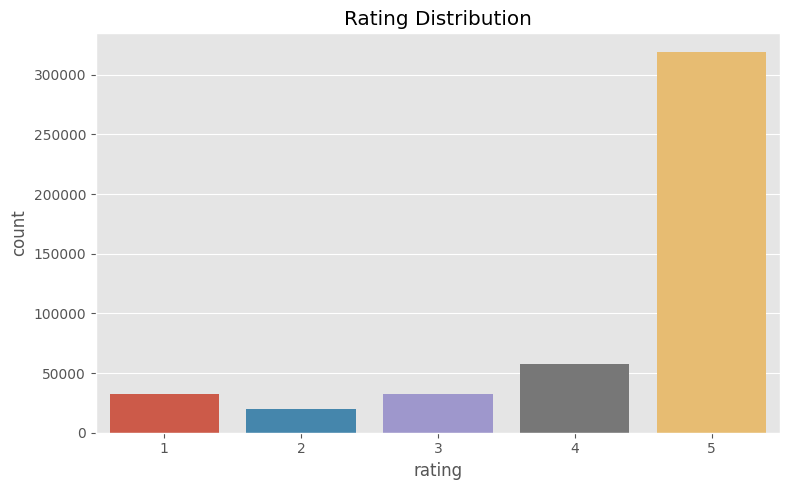

In [146]:
# Строим распределение рейтингов для оценки дисбаланса классов
plt.figure(figsize=(8,5))

sns.countplot(
    x=reviews["rating"]
)

plt.title("Rating Distribution")
plt.tight_layout()
plt.show()

В датасете наблюдается сильный дисбаланс классов: большинство отзывов имеют положительный рейтинг (4–5 звезд ≈ 82%), тогда как neutral и negative классы представлены значительно слабее. Это типично для real-world review datasets и требует учета imbalance при обучении моделей.

In [147]:
# Проверяем, сколько отзывов оставлено после подтвержденной покупки
reviews["verified_purchase"].value_counts()

verified_purchase
True     382661
False     78036
Name: count, dtype: int64

In [148]:
# Анализируем распределение голосов полезности отзыва
reviews["helpful_vote"].describe()

count    460697.000000
mean          0.917438
std          11.256480
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        3429.000000
Name: helpful_vote, dtype: float64

## 5. Sentiment Analysis (Supervised Learning)

### Разметка тональности (Sentiment Labeling)

Преобразование звездных рейтингов в целевые классы: negative, neutral и positive.

In [149]:
# Проверяем допустимые значения рейтингов
reviews["rating"].value_counts().sort_index()

# Преобразуем рейтинг в целевую метку тональности
sentiment_conditions = [
    reviews["rating"].isin([1, 2]),
    reviews["rating"].eq(3),
    reviews["rating"].isin([4, 5])
]

sentiment_labels = [
    "negative",
    "neutral",
    "positive"
]

reviews["sentiment_label"] = np.select(
    sentiment_conditions,
    sentiment_labels,
    default=np.nan
)

# Проверяем наличие неизвестных sentiment-классов
print(reviews["sentiment_label"].isna().sum())
assert reviews["sentiment_label"].isna().sum() == 0

0


Данные несбалансированы как говорилось выше и большинство отзывов относится к positive-классу. 

Поэтому при обучении модели важно оценивать не только accuracy, 
но и precision, recall и F1-score по каждому классу.

### Text EDA по sentiment-классам

Анализ длины очищенного текста, примеров отзывов по классам тональности, наиболее частых слов и биграмм

In [150]:
# Добавляем длину очищенного текста
reviews["clean_text_length"] = reviews["clean_text"].str.len()

reviews["clean_text_length"].describe()

count    460697.000000
mean        266.952869
std         310.172273
min           7.000000
25%          92.000000
50%         173.000000
75%         326.000000
max       15542.000000
Name: clean_text_length, dtype: float64

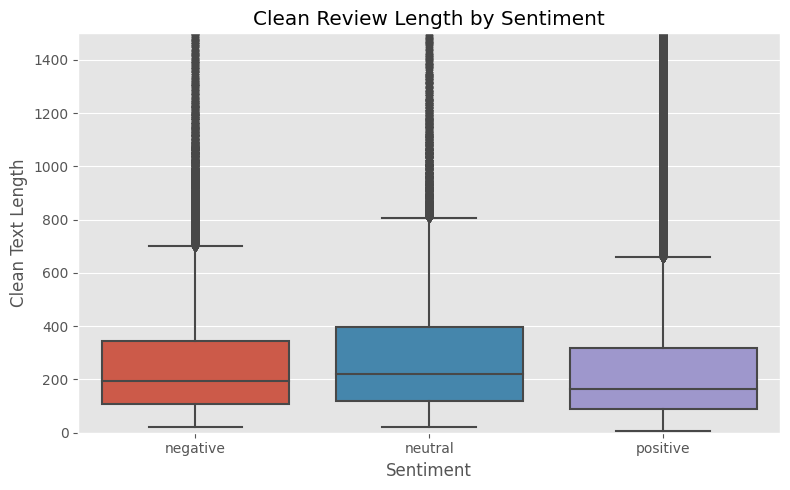

In [151]:
# Сравниваем длину отзывов по классам тональности
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=reviews,
    x="sentiment_label",
    y="clean_text_length",
    order=["negative", "neutral", "positive"]
)

plt.title("Clean Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Clean Text Length")
plt.ylim(0, 1500)
plt.tight_layout()
plt.show()

In [152]:
# Смотрим случайные примеры отзывов из каждого класса
reviews[
    ["rating", "sentiment_label", "text", "clean_text"]
].groupby("sentiment_label", group_keys=False).apply(
    lambda x: x.sample(3, random_state=42)
)

,rating,sentiment_label,text,clean_text
210760,1,negative,These plate stands open all the way flat which is not supportive for valuable plates. They tip easily. Very disappointed and do not recommend.,cheap these plate stands open all the way flat which is not supportive for valuable plates they tip easily very disappointed and do not recommend
354669,2,negative,"This was way thinner than expected, allowed in way too much light and heat. Returned for thicker.",blocks very little light but is a nice looking curtain if you just want it for show this was way thinner than expected allowed in way too much light and heat returned for thicker
22952,1,negative,Cheap quality small. One of the photos made it look like it was bigger than it is I could go into a crafts store and pale lot less for this piece of junk.,this is very cheap quality and small you could make it cheaper by yourself cheap quality small one of the photos made it look like it was bigger than it is i could go into a crafts store and pale ...
445692,3,neutral,"This shelf isn't as nice as I hoping it would be. Most of it is actually particle board instead of real wood. The dream catchers are very cheaply made, I even had to reattach some of the feathers ...",not as good as i was hoping this shelf is not as nice as i hoping it would be most of it is actually particle board instead of real wood the dream catchers are very cheaply made i even had to reat...
4841,3,neutral,"This is a different idea to steam a small amount<br />Of food!<br /><br /> You have to put this steamer top over a pan with water to get the steam<br />To your food.<br />I understand, I use a reg...",does not hold 2 pieces of salmon very small no lid to steam with this is a different idea to steam a small amount of food you have to put this steamer top over a pan with water to get the steam to...
234943,3,neutral,"Not Silicone, though description says they are. I wouldn't wash these in dishwasher. I ordered several batches of these bags in different brands and none of them hold up well in the dishwasher. Th...",dishwasher safe not silicone not silicone though description says they are i would not wash these in dishwasher i ordered several batches of these bags in different brands and none of them hold up...
252853,5,positive,Machine wash and dry well. Wear well. Minimal shrinkage after wash. Soft. Absorbent. Bright coloring that does not fade super quickly. Good value. No complaints or regrets.,nice kitchen towel set machine wash and dry well wear well minimal shrinkage after wash soft absorbent bright coloring that does not fade super quickly good value no complaints or regrets
172516,5,positive,"Easy to use, adjust and see!",nice easy to use adjust and see
134161,5,positive,These are your typical quilted jelly jars. Lids fit perfectly and the glass is thick and very difficult to break. I recommend these to anyone who cans small portion. If course they can be used ...,as good as the original brand these are your typical quilted jelly jars lids fit perfectly and the glass is thick and very difficult to break i recommend these to anyone who cans small portion if ...


In [153]:
# Собираем самые частые слова в очищенных отзывах
all_words = " ".join(reviews["clean_text"]).split()

word_counts = Counter(all_words)

word_counts.most_common(30)

[('the', 1048112),
 ('i', 780628),
 ('it', 717861),
 ('and', 700676),
 ('to', 605487),
 ('a', 585668),
 ('is', 448045),
 ('for', 374010),
 ('this', 335622),
 ('of', 299358),
 ('not', 290280),
 ('in', 262347),
 ('my', 244282),
 ('but', 201948),
 ('that', 200174),
 ('are', 191266),
 ('have', 183678),
 ('on', 183540),
 ('with', 181320),
 ('great', 176190),
 ('so', 175170),
 ('they', 167954),
 ('you', 158755),
 ('very', 155763),
 ('was', 153557),
 ('these', 134640),
 ('as', 133442),
 ('one', 106026),
 ('use', 105708),
 ('like', 105566)]

In [154]:
# Смотрим самые частые смысловые слова после удаления stopwords
all_words_no_stopwords = " ".join(
    reviews["clean_text_no_stopwords"]
).split()

word_counts_no_stopwords = Counter(all_words_no_stopwords)

word_counts_no_stopwords.most_common(30)

[('not', 290280),
 ('great', 176190),
 ('use', 105708),
 ('like', 105566),
 ('love', 103328),
 ('good', 98712),
 ('easy', 98593),
 ('nice', 96680),
 ('just', 91427),
 ('perfect', 70587),
 ('really', 61885),
 ('quality', 59062),
 ('little', 53040),
 ('does', 51079),
 ('works', 49099),
 ('product', 48089),
 ('size', 46268),
 ('time', 46022),
 ('set', 42846),
 ('small', 42726),
 ('sturdy', 41836),
 ('used', 41541),
 ('price', 41066),
 ('did', 40032),
 ('bought', 39353),
 ('clean', 39107),
 ('looks', 38472),
 ('look', 37126),
 ('work', 36629),
 ('beautiful', 35211)]

После удаления stopwords наиболее частыми стали содержательные слова, связанные с пользовательским опытом и характеристиками товара:  
`great`, `easy`, `love`, `good`, `quality`, `size`, `clean`, `sturdy`, `price`.

Отзывы часто фокусируются на качестве товара, удобстве использования, размере, внешнем виде и соотношении цены и ценности продукта.

In [155]:
# Функция для поиска самых частых слов внутри одного sentiment-класса
def get_top_words_by_sentiment(sentiment, n=20):
    texts = reviews.loc[
        reviews["sentiment_label"] == sentiment,
        "clean_text_no_stopwords"
    ]

    words = " ".join(texts).split()
    word_counts = Counter(words)

    return pd.DataFrame(
        word_counts.most_common(n),
        columns=["word", "count"]
    )

In [156]:
negative_top_words = get_top_words_by_sentiment("negative", n=20)
negative_top_words

,word,count
0,not,68143
1,like,11811
2,just,10801
3,use,10084
4,does,8889
5,did,7937
6,product,7502
7,time,6778
8,good,6690
9,quality,6669


In [157]:
neutral_top_words = get_top_words_by_sentiment("neutral", n=20)
neutral_top_words

,word,count
0,not,42558
1,like,9982
2,just,8511
3,use,7810
4,good,7097
5,does,6520
6,nice,5526
7,great,5335
8,small,5049
9,really,4981


In [158]:
positive_top_words = get_top_words_by_sentiment("positive", n=20)
positive_top_words

,word,count
0,not,179579
1,great,166155
2,love,99218
3,easy,92594
4,nice,87887
5,use,87814
6,good,84925
7,like,83773
8,just,72115
9,perfect,68527


После раскрытия английских сокращений слово `not` стало самым частым во всех sentiment-классах. Это ожидаемо, потому что в отзывах часто встречаются конструкции с отрицанием. Для будущей модели `not` лучше сохранить, так как оно меняет смысл фразы (`good` и `not good` имеют разную тональность).

Позитивные отзывы чаще содержат слова `great`, `easy`, `love`, `perfect`, `works`, `sturdy`, что связано с высокой оценкой качества и удобства товара.

В негативных отзывах чаще встречаются слова, связанные с проблемами и возвратами: `money`, `return`, `disappointed`, `work`.

При этом многие слова пересекаются между классами (`like`, `use`, `just`, `good`), поэтому простого подсчета частых слов недостаточно для надежной классификации тональности. Далее лучше использовать TF-IDF, который учитывает важность слов внутри конкретных текстов.


In [159]:
# Находим самые частые биграммы во всех очищенных отзывах
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=5_000
)

bigram_matrix = bigram_vectorizer.fit_transform(
    reviews["clean_text"]
)

bigram_counts = bigram_matrix.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_counts
}).sort_values(
    "count",
    ascending=False
).head(30)

bigram_df


,bigram,count
1193,easy use,19016
1140,easy clean,16212
4934,works great,14047
1607,good quality,11388
1969,highly recommend,10250
1786,great product,9442
2588,looks great,8200
3661,really like,7357
1133,easy assemble,7233
3222,perfect size,6871


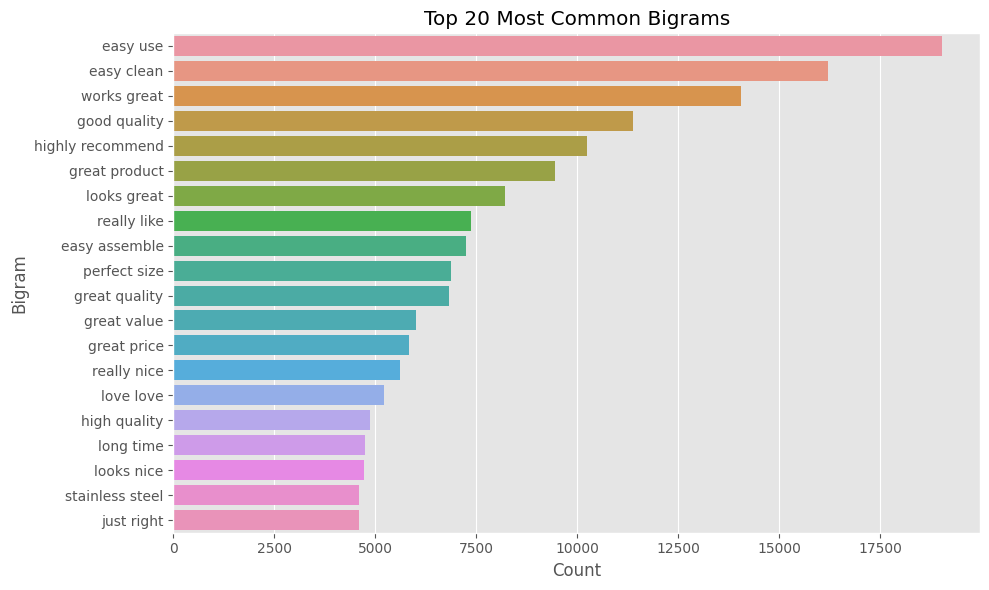

In [160]:
# Визуализируем топ-20 частых биграмм
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bigram_df.head(20),
    x="count",
    y="bigram"
)

plt.title("Top 20 Most Common Bigrams")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()


In [161]:
# Функция для поиска частых биграмм внутри sentiment-класса
def get_top_bigrams_by_sentiment(sentiment, n=20):
    texts = reviews.loc[
        reviews["sentiment_label"] == sentiment,
        "clean_text"
    ]

    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        stop_words="english",
        max_features=5_000
    )

    matrix = vectorizer.fit_transform(texts)

    counts = matrix.sum(axis=0).A1

    return pd.DataFrame({
        "bigram": vectorizer.get_feature_names_out(),
        "count": counts
    }).sort_values(
        "count",
        ascending=False
    ).head(n)


In [162]:
negative_top_bigrams = get_top_bigrams_by_sentiment("negative", n=20)
negative_top_bigrams


,bigram,count
4648,waste money,2950
3098,poor quality,1545
1160,does work,1406
4002,stopped working,1259
2502,looks like,1003
963,did work,940
4943,worth money,836
2455,look like,615
817,customer service,615
3652,save money,602


In [163]:
neutral_top_bigrams = get_top_bigrams_by_sentiment("neutral", n=20)
neutral_top_bigrams


,bigram,count
1210,easy use,510
2626,looks like,497
1186,easy clean,479
2629,looks nice,448
2110,just ok,444
1089,does work,426
1605,good quality,422
1342,feel like,390
1034,does job,386
4008,smaller expected,375


In [164]:
positive_top_bigrams = get_top_bigrams_by_sentiment("positive", n=20)
positive_top_bigrams


,bigram,count
1177,easy use,18174
1117,easy clean,15448
4945,works great,13560
1590,good quality,10569
1976,highly recommend,10121
1790,great product,9199
2584,looks great,7847
3704,really like,6795
3268,perfect size,6721
1110,easy assemble,6694


In [165]:
reviews.groupby(
    "sentiment_label"
)["helpful_vote"].mean()

sentiment_label
negative    1.379225
neutral     0.999508
positive    0.846991
Name: helpful_vote, dtype: float64

In [166]:
pd.crosstab(
    reviews["verified_purchase"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

sentiment_label,negative,neutral,positive
verified_purchase,,,
False,6.499564,6.711005,86.789431
True,12.174222,7.131377,80.694401


In [167]:
# Создаем колонку year-month для временного анализа
reviews["year_month"] = (
    reviews["timestamp"]
    .dt.to_period("M")
    .astype(str)
)

reviews[["timestamp", "year_month"]].head()

,timestamp,year_month
0,2019-06-26 13:05:49.656,2019-06
1,2022-11-20 19:27:06.340,2022-11
2,2021-01-26 01:29:41.556,2021-01
3,2019-06-19 14:22:12.796,2019-06
4,2021-05-25 16:52:44.217,2021-05


In [168]:
# Считаем количество отзывов по месяцам
reviews_per_month = reviews.groupby(
    "year_month"
).size()

reviews_per_month.head()

year_month
2019-01    8276
2019-02    5996
2019-03    7050
2019-04    6262
2019-05    6743
dtype: int64

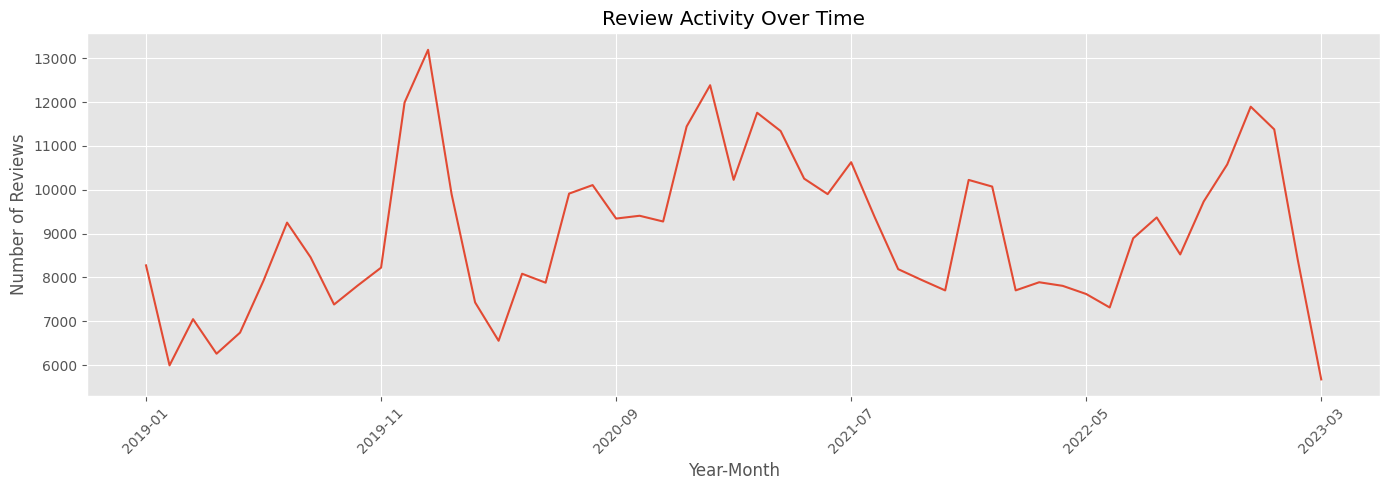

In [169]:
# Визуализируем активность отзывов по времени
plt.figure(figsize=(14, 5))

reviews_per_month.plot()

plt.title("Review Activity Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [170]:
# Считаем распределение sentiment-классов по месяцам
sentiment_over_time = pd.crosstab(
    reviews["year_month"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

sentiment_over_time.head()

sentiment_label,negative,neutral,positive
year_month,,,
2019-01,9.702755,6.222813,84.074432
2019-02,10.740494,6.187458,83.072048
2019-03,10.425532,6.921986,82.652482
2019-04,10.188438,6.898754,82.912807
2019-05,10.010381,6.525285,83.464333


<Figure size 1400x500 with 0 Axes>

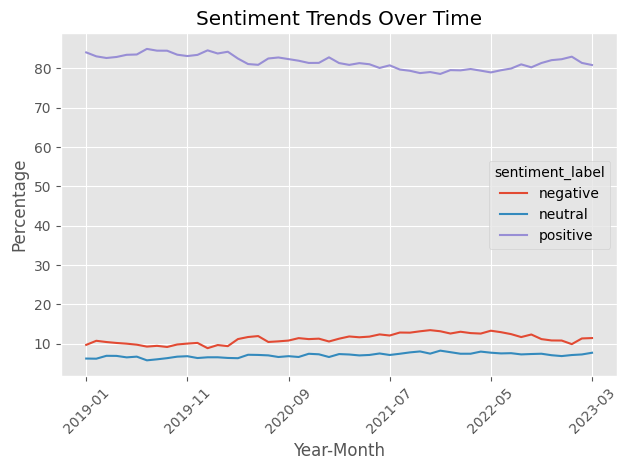

In [171]:
# Визуализируем изменение sentiment по времени
plt.figure(figsize=(14, 5))

sentiment_over_time.plot()

plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод по EDA

В ходе exploratory data analysis были выявлены следующие особенности датасета:

- Наблюдается сильный дисбаланс классов: около 82% отзывов относятся к `positive` sentiment, тогда как `neutral` и `negative` классы представлены значительно слабее.
- `Negative` reviews в среднем длиннее и содержат больше деталей, чем `positive` reviews.
- После удаления stopwords наиболее информативными стали слова, связанные с качеством товара, удобством использования и пользовательским опытом.
- Биграммы дают больше контекста, чем отдельные слова (`works great`, `highly recommend`, `waste money`, `poor quality`) и помогают лучше различать sentiment-классы.
- Между классами существует заметное пересечение по отдельным словам (`good`, `like`, `use`), поэтому для дальнейшего моделирования используется TF-IDF с unigrams и bigrams.
- `Negative` reviews получают больше helpful votes в среднем, что может указывать на более подробные и информативные отзывы при негативном пользовательском опыте.
- Verified buyers оставляют больше негативных отзывов, чем non-verified users, несмотря на доминирование positive sentiment в обеих группах.
- Time analysis показывает, что пользовательская активность меняется со временем: количество отзывов колеблется по месяцам, что отражает динамический характер real-world review data.
- Анализ sentiment trends over time показывает, что positive reviews стабильно доминируют на протяжении всего периода наблюдений, тогда как доля negative и neutral отзывов остается относительно стабильной.

Полученные результаты подтверждают, что датасет отражает реалистичное поведение пользователей и хорошо подходит для построения production-style NLP pipeline и customer review analytics system.

###  Разделение датасета на train и test выборки с сохранением пропорций классов (stratification)

In [172]:
# Выбираем текст как признак, а sentiment_label как целевую переменную
X = reviews["clean_text"]
y = reviews["sentiment_label"]

print(X.shape)
print(y.shape)

(460697,)
(460697,)


In [173]:
# Проверяем распределение классов перед разделением
y.value_counts(normalize=True) * 100

sentiment_label
positive    81.726818
negative    11.213010
neutral      7.060172
Name: proportion, dtype: float64

In [174]:
# Делим данные на train и test с сохранением пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(368557,)
(92140,)


In [175]:
# Проверяем, что распределение классов сохранилось в train и test
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)


sentiment_label
positive    81.726843
negative    11.212920
neutral      7.060238
Name: proportion, dtype: float64
sentiment_label
positive    81.726720
negative    11.213371
neutral      7.059909
Name: proportion, dtype: float64


### Извлечение TF-IDF признаков

Преобразование очищенного текста в TF-IDF признаки с использованием unigram и bigram.

In [176]:
# Параметры TF-IDF, общие для обеих Pipeline-моделей
TFIDF_PARAMS = dict(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

print("TF-IDF params defined:", TFIDF_PARAMS)

TF-IDF params defined: {'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9}


### Baseline Model 1: Logistic Regression

Train the first baseline sentiment classifier and evaluate it with classification report and confusion matrix.

In [177]:
# Путь к сохраненной модели
log_reg_model_path = "models/log_reg_pipeline.joblib"

# Создаем Pipeline: TF-IDF → Logistic Regression
# Каждая модель обучается в собственной Pipeline для исключения data leakage

pipe_log_reg = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# Если модель уже существует — загружаем
if os.path.exists(log_reg_model_path):

    pipe_log_reg = joblib.load(
        log_reg_model_path
    )

    print("Logistic Regression model loaded")

# Иначе обучаем и сохраняем
else:

    pipe_log_reg.fit(X_train, y_train)

    joblib.dump(
        pipe_log_reg,
        log_reg_model_path
    )

    print("Logistic Regression model trained and saved")

Logistic Regression model loaded


In [178]:
# Предсказания Logistic Regression
y_pred_log_reg = pipe_log_reg.predict(X_test)

# Вероятности классов
y_proba_log_reg = pipe_log_reg.predict_proba(X_test)

# Максимальная вероятность = confidence score
confidence_log_reg = y_proba_log_reg.max(axis=1)

In [179]:
# Таблица предсказаний
predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_log_reg,
    "confidence": confidence_log_reg
})

predictions_df.head()

,text,true_label,predicted_label,confidence
0,i love it i bought this because it is pretty and the green one reminds me of my parrot it looks like the picture,positive,positive,0.850718
1,good size cute and durable i originally ordered the goose one liked it so much i ordered the fox it is a perfect sized coffee cup i can put abut 12 1 2 oz coffee or tea in comfortably it has a sle...,positive,positive,0.972558
2,you get what you pay for not that bad though if you just need an extra cover for a guest room or something this is perfect it s cheap and simple but the size is a little larger than it should be b...,neutral,neutral,0.871125
3,wow so much more than i anticipated while this may appear like a fancy update on a beanbag style chair it is so much more than that this low sitting chair will quickly become a favorite for people...,positive,positive,0.936575
4,great no slip treads easy to adhere to a clean surface used alcohol on the surface as implied in instructions have been in place through numerous baths and showers with no problem,positive,positive,0.943753


In [180]:
# Оцениваем качество модели по каждому классу
print(classification_report(y_test, y_pred_log_reg))


              precision    recall  f1-score   support

    negative       0.70      0.75      0.73     10332
     neutral       0.32      0.60      0.42      6505
    positive       0.98      0.90      0.94     75303

    accuracy                           0.86     92140
   macro avg       0.67      0.75      0.69     92140
weighted avg       0.91      0.86      0.88     92140



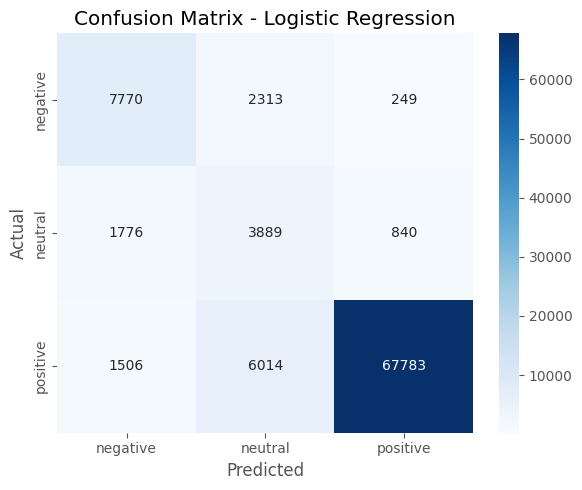

In [181]:
# Строим confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_log_reg,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Logistic Regression Performance

Базовая модель **Logistic Regression** показала:

- **Accuracy:** `0.86`
- **Macro F1-score:** `0.69`
- **Weighted F1-score:** `0.88`

Поскольку датасет сильно несбалансирован (`positive` составляет более 80% всех наблюдений), метрика **accuracy** завышает реальное качество модели. Поэтому основной акцент сделан на метриках по отдельным классам и на **Macro F1-score**.

#### Анализ по классам

- **Positive** — лучший результат:
  - Precision: `0.98`
  - Recall: `0.90`
  - F1-score: `0.94`

  Модель уверенно распознаёт положительные отзывы, что ожидаемо для самого многочисленного класса.

- **Negative** — среднее качество:
  - Precision: `0.70`
  - Recall: `0.75`
  - F1-score: `0.73`

  Большинство негативных отзывов определяется корректно, хотя часть из них всё ещё ошибочно относится к другим классам.

- **Neutral** — самый сложный класс:
  - Precision: `0.32`
  - Recall: `0.60`
  - F1-score: `0.42`

  Нейтральные отзывы (рейтинг `3`) плохо отделяются от соседних классов. Их тексты часто содержат одновременно положительные и отрицательные оценки, что затрудняет построение чёткой границы между классами.

#### Анализ ошибок

Матрица ошибок показывает, что основной источник ошибок связан с классом **neutral**. Модель часто относит такие отзывы к классам **positive** или **negative**.

С одной стороны, модель находит около **60%** нейтральных отзывов (`recall = 0.60`), однако делает это ценой большого количества ложных срабатываний, что приводит к низкому значению **precision = 0.32**.

#### Вывод

Logistic Regression формирует сильный базовый уровень качества для задачи анализа тональности. Модель хорошо справляется с крайними классами (**positive** и **negative**), однако испытывает заметные трудности с распознаванием промежуточного класса **neutral**, который является наиболее неоднозначным как с точки зрения рейтинга, так и с точки зрения содержания отзывов.

### Error Analysis

Inspect misclassified reviews to understand common model errors and label ambiguity.

In [182]:
# Собираем реальные метки, предсказания и тексты в один датафрейм
error_analysis = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "predicted_label": y_pred_log_reg
})

# Оставляем только ошибочные предсказания
errors = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
]

errors.shape


(12698, 3)

In [183]:
# Смотрим случайные ошибки модели
errors.sample(
    min(10, len(errors)),
    random_state=42
)

,text,true_label,predicted_label
293660,feel safe to not fall feel safe to not fall,positive,negative
425279,bent shelves this shelf works for my needs but i really regret not exchanging this for one in good condition,neutral,positive
451131,no stainless steel tasting coffee i really like this french press it is pretty classy i tried the coffee bags to avoid a mess the bags were too thick for the coffee to steep to its full flavor i p...,positive,negative
32161,everything ok except color for the price i got exactly what i expected thought once i got them on the tree and spread out the would look better nope cheap looking and it s definitely you get what ...,negative,neutral
51227,made in china thin bath towel set nice colors if you like thin towels these are for you they look thicker in the listing pictures than they are in person they are made of 100 cotton you ll want to...,positive,neutral
446576,good buy we measured our sink and cabinets and it measured to work only down fall is theres screws that stick out so it caused it not to fit into the adjustable slots they provide but we were able...,positive,neutral
444672,nor blackout curtains these curtains are not blackout they do filter a lot of light about 85 the color is beautiful and they are well made the description read room darkening blackout so i took a ...,positive,neutral
415722,sheds but cute used double sided carpet tape to keep in place,positive,neutral
107494,what i needed after four packs of plastic clips being broken by my four year old granddaughter testing her strength i had to find something sturdy now i just find these underneath the dining table...,positive,negative
83025,good buy doesn t have the automatic movement of our last hoover so it s a little hard to push and the lin cup fills up fast but otherwise i like it,neutral,positive


In [184]:
# Ошибки, где настоящий класс neutral
neutral_errors = errors[
    errors["true_label"] == "neutral"
]

neutral_errors.sample(
    min(10, len(neutral_errors)),
    random_state=42
)

,text,true_label,predicted_label
53105,great heater for rv so i thought heater heats my 2006 38 5th wheel it gets very hot in seconds it is a very noisy but does the job i do keep heater clean twice weekly i blow out dust lint with a c...,neutral,positive
268382,duvet insert i did not like the fact that the material on the outside of the insert is a paper based product similar to reusable bags at the grocery store it is lightweight and am using it in my d...,neutral,positive
414500,return but not for fault to small for my prjoect they look bigger in the picture when getting them out of the box nope not going to work retuning as we speak,neutral,negative
427324,shoes do not stay on the shoe rack this it is not a good shoe rack the shoes fall off because the metal bars are slanted so the slightest touch or disturbance to the shoe rack in the shoes come tu...,neutral,negative
385387,mason jar ready not so much to my way of thinking mason jar ready means you screw on a regular mouth mason jar and bobs yer uncle but this isn t that instead it s an adaptor that only works withou...,neutral,positive
451121,do not know never used it my puppy was potty trained by the time i received this lol i was able to train my golden retriever potty train him by 3 months and 1 week old i ordered this a little too ...,neutral,positive
161652,wouldn t recommend did not like the quality one of them was super see through and it just didn t look a good quality overall,neutral,negative
18923,regret my purchase fruit is unnaturally bright and shiny except for the way too pale peaches not happy at all,neutral,negative
261258,two rods were bent received with a few rods bent and not as level once installed also instructions could have been more clear for those of us working in a tighter space between cabinet and wall ov...,neutral,positive
295161,very rough and scratchy texture they are not soft towels they have a very rough texture not what i expected,neutral,negative


In [185]:
# Ошибки, где настоящий класс negative
negative_errors = errors[
    errors["true_label"] == "negative"
]

negative_errors.sample(
    min(10, len(negative_errors)),
    random_state=42
)

,text,true_label,predicted_label
235654,infrequently we just must know from where whom items come i am disabled must sleep in recliner thought it might be a nice option for my beloved bucky but then i discovered who made it will never a...,negative,positive
238078,the cover doesn t fit would be an excellent product if only the cover fit easy to read easy to clean nice and sturdy but the cover doesn t fit,negative,neutral
473462,meh seems like it is a decent pitcher i have not used it yet though because it is so much smaller than i expected i was planning on something that would hold a larger amount of liquid for drinks d...,negative,neutral
367994,canceled canceled the order so i do not know how good it is,negative,positive
95726,my wife received these as a gift my wife received these as a gift they are crudely constructed and had chipped paint so i had to paint them and still they look crude i sewed covers for the metal p...,negative,neutral
339538,not as strong as it looks i was disappointed in the beaters and the power of this mixer,negative,neutral
448750,warning cheap looking lightweight disappointing these martini glasses were purchased on a lightning deal for under 12 and i still feel ripped off i question whether the glasses i received are the ...,negative,neutral
72963,unnecessarily frustrating starts out by adjusting seconds then abruptly jumps to adjusting minutes then back to seconds i end up having to turn it back and forth at varying speeds to get the corre...,negative,neutral
174019,nice item its a good shower curtain nothing fancy but good for a guess or kids bathroom,negative,positive
37199,made in china better options abound first of all i find that this chair is more for a petite person other than the arms moving up and down there are not a lot of adjustments that can be made with ...,negative,neutral


In [186]:
# Самые уверенные предсказания
predictions_df.sort_values(
    "confidence",
    ascending=False
).head(10)

,text,true_label,predicted_label,confidence
17681,definitely what do recommend love this product oh my god i love this organizer i am about to buy 5 more of them in white for my kids rooms i love them they are amazing they are super sturdy and th...,positive,positive,0.999998
23181,perfect for griller s great quality and so easy to use happy with them,positive,positive,0.999997
78599,excellent hooks highly recommend sturdy and easy to install great value thank you,positive,positive,0.999996
20238,best absolutely perfect love it so much perfect for my tea,positive,positive,0.999996
2229,5 7 rug excellent perfect,positive,positive,0.999996
1523,a peice of junk flimsy garbage not wort one star,negative,negative,0.999996
55052,love it this works perfectly i absolutely love it,positive,positive,0.999996
13865,love it i love this it is perfect,positive,positive,0.999996
89412,very happy just what i needed awesome,positive,positive,0.999993
83594,love it great product allows great airflow works well easy to clean,positive,positive,0.999993


In [187]:
# Самые неуверенные предсказания
predictions_df.sort_values(
    "confidence",
    ascending=True
).head(10)

,text,true_label,predicted_label,confidence
68309,picks up dirt easy gets dirty easy and very hard to clean,negative,positive,0.336852
48918,very impressed with my first bed in a box being constantly on the go has made me reluctant to buy a real bed i have been on beds that are either portable or easy to disassemble like futons for the...,positive,negative,0.337483
76112,thick curtain this is a good shower curtain it is a nice weight definitely not flimsy but the color is way off from what is advertised,neutral,neutral,0.338505
33448,slippery i have used it daily for quite a while now no loss in the surface,positive,negative,0.339324
50288,incense sticks i like smell of perfume let sit in my room with out burned it,positive,positive,0.339548
4246,arrive a day late for a party so far these seem like good quality and work well but i ve only had them on for 15 20 minutes i m not sure if i will keep them yet i ordered in plenty of tube for arr...,positive,positive,0.339615
1351,high quality but too high and too hard i m a total side sleeper and always used shallow and soft pillows that allow my head to contour easily the description mentions it being soft and cozy memory...,neutral,neutral,0.339951
88112,quality and not uncomfortable i have not spilled my coffee in the morning yet but i can tell if i do it will not soak this,positive,positive,0.340153
17867,strange these mirrors are adorable and well made but why on earth did i receive two mirrors with completely different chain colors and two different chain lengths makes it kind of hard to hang nex...,neutral,neutral,0.340312
26181,no water plug it is an iron it does the ironing the only thing that drives me batty is there is no plug for the water hole so one wrong move and it splashes everywhere,neutral,positive,0.340689


In [188]:
# Самые уверенные ошибки 
confident_errors = predictions_df[
    predictions_df["true_label"] !=
    predictions_df["predicted_label"]
]

confident_errors.sort_values(
    "confidence",
    ascending=False
).head(10)

,text,true_label,predicted_label,confidence
22104,great value versatile love them versatile,neutral,positive,0.999974
62594,love it beautiful just what i expected,negative,positive,0.999374
17034,labeling all my new storage containers these are great totally happy with them,neutral,positive,0.998788
54783,perfect perfect for what i needed,negative,positive,0.998665
14899,great product easy to use and great price,negative,positive,0.997846
19928,k cup holder i love it it was exactly what i was looking for holds a great amount of k cups,neutral,positive,0.997765
59061,just ok average nothing special kinda looks quickly put together but does the job,positive,neutral,0.997759
80798,super nice very nice highly recommend it is nice and deep fits perfect as my mattress is super high took to ling to get here tho,neutral,positive,0.997706
57709,cheap chinese junk this is cheap chinese junk that americans are paying too dollars for,neutral,negative,0.997284
23861,perfect fit perfect fit in our kitchen sink easy to clean,neutral,positive,0.996849


Анализ confidence scores показывает, что модель очень уверенно классифицирует типичные позитивные отзывы. Самые confident predictions содержат явно положительные фразы: `excellent perfect`, `works great`, `highly recommend`, `great quality`, `easy to install`. Для таких отзывов confidence модели близок к `1.0`.

Наименее уверенные предсказания обычно связаны с длинными и неоднозначными отзывами, где одновременно присутствуют как позитивные, так и негативные элементы. Например:
- положительный рейтинг + жалобы на качество или конструкцию;
- негативный опыт, описанный без явно эмоциональных слов;
- смешанные отзывы с одновременно позитивными и негативными характеристиками товара.

Класс `neutral` оказался самым сложным для модели. Многие отзывы с рейтингом `3` содержат явно эмоциональные слова (`perfect`, `love`, `disappointed`, `buyer beware`), поэтому модель часто относит их к `positive` или `negative`. Это подтверждает, что rating `3` не всегда соответствует действительно нейтральному тексту.

Особенно интересны confident errors — ошибки, сделанные моделью с очень высокой уверенностью. Например:
- `no brained perfect`
- `love them versatile`
- `returned product disappointed`
- `perfect for what i needed`

В подобных случаях модель ориентируется на сильные sentiment-слова (`perfect`, `love`, `disappointed`), тогда как истинная метка формируется из numerical rating. Это еще раз показывает ограничение weak supervision: рейтинг и реальная тональность текста не всегда совпадают.

Также видно, что часть ошибок возникает на коротких отзывах или фразах без достаточного контекста. Такие тексты сложнее интерпретировать даже человеку.

Главный вывод: ошибки связаны не только с качеством модели, но и с природой данных. Мы используем weak labels, построенные на основе ratings, однако numerical rating не всегда отражает фактическую эмоциональную тональность текста. Это является одной из ключевых причин путаницы между классами `negative`, `neutral` и `positive`.


### Baseline Model 2: LinearSVC

Обучение второй baseline-модели на TF-IDF признаках и сравнение её результатов с Logistic Regression.

In [189]:
# Путь к сохраненной модели
svc_model_path = "models/svc_pipeline.joblib"

# Создаем Pipeline: TF-IDF -> Calibrated LinearSVC
# LinearSVC сам по себе не дает вероятностей, поэтому оборачиваем его в
# CalibratedClassifierCV: это добавляет predict_proba (confidence score),
# которым мы пользуемся в error- и mismatch-анализе, и делает SVC единой
# моделью для анализа и деплоя.
# Каждая модель обучается в собственной Pipeline для исключения data leakage.

pipe_svc = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf", CalibratedClassifierCV(
        LinearSVC(
            class_weight="balanced",
            random_state=42
        ),
        method="sigmoid",
        cv=3
    ))
])

# Если модель уже существует — загружаем
if os.path.exists(svc_model_path):

    pipe_svc = joblib.load(
        svc_model_path
    )

    print("LinearSVC model loaded")

# Иначе обучаем и сохраняем
else:

    pipe_svc.fit(X_train, y_train)

    joblib.dump(
        pipe_svc,
        svc_model_path
    )

    print("LinearSVC model trained and saved")

LinearSVC model loaded


In [190]:
# Делаем предсказания LinearSVC на тестовой выборке
y_pred_svc = pipe_svc.predict(X_test)

In [191]:
# Оцениваем качество LinearSVC
print(classification_report(y_test, y_pred_svc))


              precision    recall  f1-score   support

    negative       0.75      0.77      0.76     10332
     neutral       0.49      0.17      0.26      6505
    positive       0.93      0.98      0.96     75303

    accuracy                           0.90     92140
   macro avg       0.72      0.64      0.66     92140
weighted avg       0.88      0.90      0.89     92140



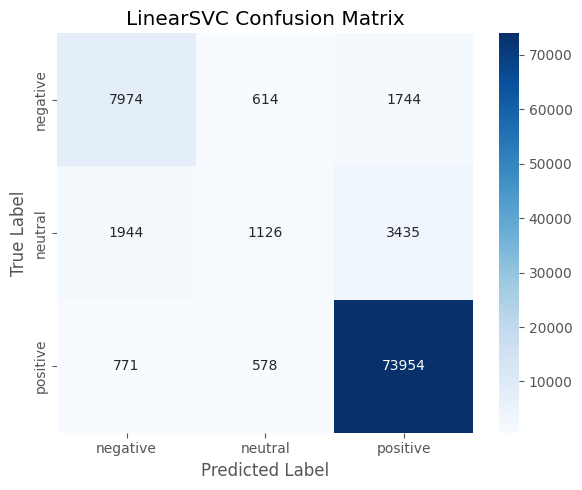

In [192]:
# Confusion matrix для LinearSVC
cm_svc = confusion_matrix(
    y_test,
    y_pred_svc
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipe_svc.classes_,
    yticklabels=pipe_svc.classes_
)

plt.title("LinearSVC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Baseline Model 2: LinearSVC

Базовая модель **LinearSVC** (откалиброванная через `CalibratedClassifierCV` для получения вероятностей) показала:

- **Accuracy:** `0.90`
- **Macro F1-score:** `0.66`
- **Weighted F1-score:** `0.89`

По значениям **accuracy** и **weighted F1-score** модель демонстрирует лучший результат среди протестированных baseline-моделей. Однако более высокий общий результат достигается за счёт поведения на классе `neutral`.

#### Анализ по классам

- **Positive** — лучший результат:
  - Precision: `0.93`
  - Recall: `0.98`
  - F1-score: `0.96`

  Модель практически безошибочно распознаёт положительные отзывы и показывает очень высокий recall для самого многочисленного класса.

- **Negative** — стабильное качество:
  - Precision: `0.75`
  - Recall: `0.77`
  - F1-score: `0.76`

  По сравнению с Logistic Regression качество на негативном классе немного улучшилось.

- **Neutral** — самый проблемный класс:
  - Precision: `0.49`
  - Recall: `0.17`
  - F1-score: `0.26`

  Несмотря на рост precision, модель практически перестала находить нейтральные отзывы. Большинство объектов класса `neutral` классифицируется как `positive` или `negative`.

#### Анализ ошибок

По сравнению с Logistic Regression модель стала значительно более консервативной при присвоении метки **neutral**. Precision вырос с `0.32` до `0.49`, однако recall резко снизился с `0.60` до `0.17`.

Это означает, что LinearSVC крайне редко предсказывает класс `neutral`, предпочитая относить спорные отзывы к классам **positive** или **negative**. Такой подход позволяет уменьшить количество ложноположительных предсказаний для нейтрального класса, но приводит к потере большинства действительно нейтральных отзывов.

#### Вывод

LinearSVC показывает лучшие результаты по **accuracy** и **weighted F1-score**, а также обеспечивает высокое качество на классах **positive** и **negative**. Однако модель достигает этого за счёт существенного ухудшения качества на классе **neutral**, что отражается в снижении **macro F1-score**.

Таким образом, LinearSVC оптимизирует общую точность классификации и качество на доминирующем классе, но менее эффективно справляется с распознаванием нейтральных отзывов.

### Baseline Model 3: LightGBM

Обучение baseline-модели на основе gradient boosting и сравнение её результатов с линейными моделями.
LightGBM добавлен как non-linear baseline для сравнения с linear models на sparse TF-IDF features.

In [193]:
# Путь к сохраненной модели
lgbm_model_path = "models/lightgbm_pipeline.joblib"

# Создаем Pipeline: TF-IDF → LightGBM
# Каждая модель обучается в собственной Pipeline для исключения data leakage

pipe_lgbm = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf", LGBMClassifier(
        class_weight="balanced",
        n_estimators=300,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

# Если модель уже существует — загружаем
if os.path.exists(lgbm_model_path):

    pipe_lgbm = joblib.load(
        lgbm_model_path
    )

    print("LightGBM model loaded")

# Иначе обучаем и сохраняем
else:

    pipe_lgbm.fit(X_train, y_train)

    joblib.dump(
        pipe_lgbm,
        lgbm_model_path
    )

    print("LightGBM model trained and saved")

LightGBM model loaded


In [194]:
# Делаем предсказания LightGBM на тестовой выборке
y_pred_lgbm = pipe_lgbm.predict(X_test)

c:\Users\Chuni\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [195]:
# Оцениваем качество LightGBM по каждому классу
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

    negative       0.71      0.75      0.73     10332
     neutral       0.32      0.62      0.42      6505
    positive       0.98      0.89      0.94     75303

    accuracy                           0.86     92140
   macro avg       0.67      0.76      0.70     92140
weighted avg       0.91      0.86      0.88     92140



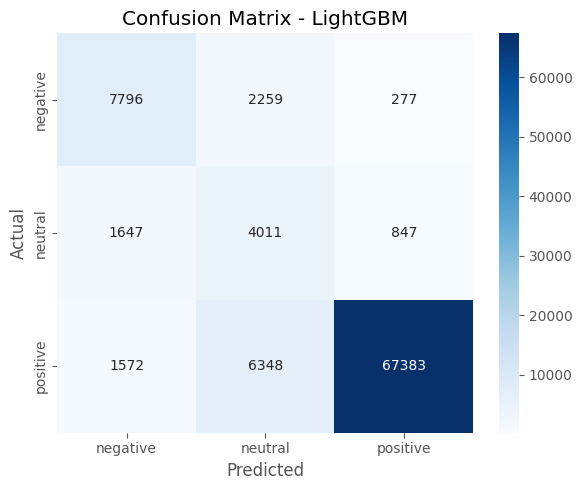

In [196]:
# Строим confusion matrix для LightGBM
cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Baseline Model 3: LightGBM

Базовая модель **LightGBM** показала:

- **Accuracy:** `0.86`
- **Macro F1-score:** `0.70`
- **Weighted F1-score:** `0.88`

По общему качеству модель демонстрирует результаты, близкие к Logistic Regression. При этом LightGBM показывает лучший **macro F1-score** среди протестированных моделей, что говорит о более сбалансированном качестве между всеми классами.

#### Анализ по классам

- **Positive** — лучший результат:
  - Precision: `0.98`
  - Recall: `0.89`
  - F1-score: `0.94`

  Модель уверенно распознаёт положительные отзывы, хотя recall немного ниже по сравнению с LinearSVC.

- **Negative** — стабильное качество:
  - Precision: `0.71`
  - Recall: `0.75`
  - F1-score: `0.73`

  Качество на негативном классе сопоставимо с Logistic Regression.

- **Neutral** — самый сложный класс:
  - Precision: `0.32`
  - Recall: `0.62`
  - F1-score: `0.42`

  LightGBM показывает лучший recall для класса `neutral` среди всех протестированных моделей, однако достигает этого ценой большого количества ложноположительных предсказаний, что приводит к низкому precision.

#### Анализ ошибок

Матрица ошибок показывает, что основной источник ошибок, как и в других моделях, связан с классом **neutral**. Однако в отличие от LinearSVC модель активно пытается выделять нейтральные отзывы и находит более 60% объектов этого класса.

Такой подход позволяет сохранить высокий recall для `neutral`, но приводит к частому смешиванию нейтральных отзывов с классами **positive** и **negative**, что ограничивает значение precision.

#### Вывод

LightGBM демонстрирует наиболее сбалансированное качество между всеми тремя классами и достигает лучшего **macro F1-score (`0.70`)** среди протестированных baseline-моделей.

В отличие от LinearSVC, который практически игнорирует класс `neutral`, LightGBM сохраняет высокий recall для нейтральных отзывов и обеспечивает более равномерное качество классификации. Несмотря на отсутствие преимущества по accuracy, такая сбалансированность делает модель сильным кандидатом для задач, где важно корректно распознавать все классы, а не только доминирующий класс `positive`.

### Финальное сравнение моделей

Сводное сравнение метрик Logistic Regression, LinearSVC и LightGBM в одной таблице.

In [197]:
# Compare models by key metrics
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "LinearSVC",
        "LightGBM"
    ],
    "accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "macro_f1": [
        f1_score(y_test, y_pred_log_reg, average="macro"),
        f1_score(y_test, y_pred_svc, average="macro"),
        f1_score(y_test, y_pred_lgbm, average="macro")
    ],
    "weighted_f1": [
        f1_score(y_test, y_pred_log_reg, average="weighted"),
        f1_score(y_test, y_pred_svc, average="weighted"),
        f1_score(y_test, y_pred_lgbm, average="weighted")
    ]
})

model_comparison

,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.862188,0.694156,0.879287
1,LinearSVC,0.901389,0.657214,0.885814
2,LightGBM,0.859453,0.695671,0.877390


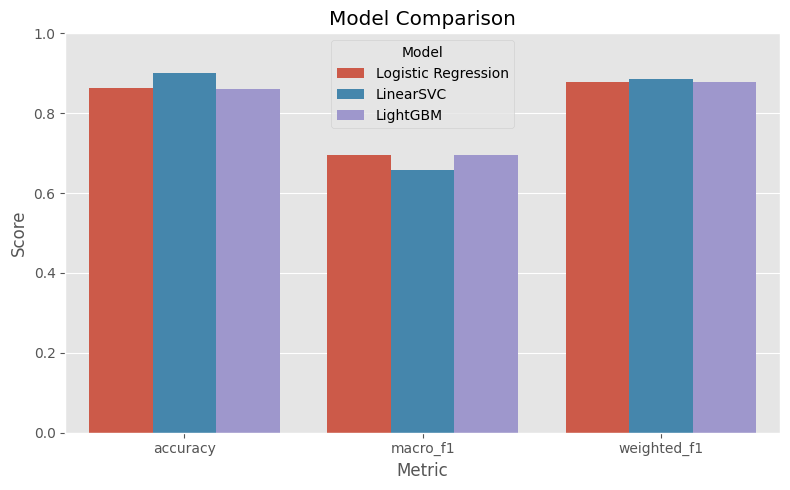

In [198]:
# Visualize model comparison
model_comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison_melted,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

#### Итоговое сравнение моделей

| Модель | Accuracy | Macro F1 | Weighted F1 |
|----------|----------|----------|----------|
| Logistic Regression | 0.862 | 0.694 | 0.879 |
| LinearSVC (calibrated) | **0.901** | 0.657 | **0.886** |
| LightGBM | 0.859 | **0.696** | 0.877 |

Полученные результаты показывают, что выбор лучшей модели зависит от используемой метрики.

- По **accuracy** и **weighted F1-score** уверенно лидирует **LinearSVC**, что объясняется очень высоким качеством на доминирующем классе `positive`.
- По **macro F1-score**, который учитывает все классы одинаково, **LightGBM** (`0.696`) и **Logistic Regression** (`0.694`) показывают практически одинаковый результат и заметно превосходят LinearSVC (`0.657`).
- Основное различие между моделями связано с классом `neutral`. Logistic Regression и LightGBM сохраняют высокий recall для нейтральных отзывов, тогда как LinearSVC предпочитает относить спорные примеры к классам `positive` или `negative`.

В качестве финальной модели выбран **LinearSVC**. Несмотря на более низкий macro F1-score, модель обеспечивает лучшую общую точность классификации (`accuracy = 0.901`) и максимальный `weighted F1-score = 0.886`, что особенно важно в условиях сильного дисбаланса классов. Дополнительным преимуществом является высокая скорость обучения и инференса на разреженных TF-IDF признаках, а использование `CalibratedClassifierCV` позволяет получать вероятности классов для последующего анализа уверенности модели.

Недостатком выбранного подхода остаётся низкий recall класса `neutral`, поэтому в задачах, где критически важно одинаковое качество по всем классам, более предпочтительным выбором могут быть Logistic Regression или LightGBM.

Интересно, что **LightGBM как нелинейная модель не продемонстрировал преимущества над линейными алгоритмами**. Для высокоразмерных разреженных TF-IDF признаков это является типичной ситуацией: линейные методы часто оказываются не только быстрее, но и эффективнее более сложных моделей.

## 6. Topic Modeling (Unsupervised Learning)

In [199]:
# Sampling reviews для topic modeling 200k строк достаточно для качественного topic modeling, при этом не перегружая память и ускоряя обучение модели
topic_reviews = reviews.sample(
    200_000,
    random_state=42
)

In [200]:
# Используем очищенный текст без stopwords
topic_texts = topic_reviews[
    "clean_text_no_stopwords"
]

topic_texts.head()

157817                                                                                                                            love best purchase great pancake waffle batter straining kefir grains best size
220628                                                                                         great works great straw storage not alot say heavy weight straws look beautiful lid lifts expose straws dispensing
311986                                                                                                                           easy use like easier use baking soda fits better work really like bags refreshed
206500                                                                           shines polished stone nicely beautifully shined granite marble smells great highly recommend product works great stainless steel
161174    great tub shower cleaning purchased getting older reaching tub scrub tile surround getting harder brush easily reach corners nooks crannies fixtures h

In [201]:
# Создаем CountVectorizer для topic modeling
# Используем unigrams и bigrams
# Удаляем слишком редкие и слишком частые слова

topic_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.5,
    max_features=10_000
)

In [202]:
# Преобразуем тексты в count-based матрицу признаков
topic_matrix = topic_vectorizer.fit_transform(
    topic_texts
)

topic_matrix.shape

(200000, 10000)

In [203]:
# Смотрим размер словаря CountVectorizer
len(topic_vectorizer.get_feature_names_out())

10000

Для topic modeling используется CountVectorizer вместо TF-IDF, поскольку LDA работает на count-based features и анализирует совместную встречаемость слов внутри документов.

Использование unigrams и bigrams помогает модели лучше выделять пользовательские темы и customer pain points.

In [204]:
# Путь к сохраненной LDA модели
lda_model_path = "models/lda_model.joblib"

# Создаем LDA модель
lda_model = LatentDirichletAllocation(
    n_components=12,
    random_state=42,
    learning_method="batch",
    max_iter=30
)

# Если модель уже существует — загружаем
if os.path.exists(lda_model_path):

    lda_model = joblib.load(
        lda_model_path
    )

    print("LDA model loaded")

# Иначе обучаем и сохраняем
else:

    lda_model.fit(topic_matrix)

    # Сохраняем LDA модель
    joblib.dump(
        lda_model,
        lda_model_path
    )

    # Сохраняем CountVectorizer
    joblib.dump(
        topic_vectorizer,
        "models/topic_vectorizer.joblib"
    )

    print("LDA model trained and saved")

LDA model loaded


In [205]:
# Получаем слова из CountVectorizer
feature_names = topic_vectorizer.get_feature_names_out()

In [206]:
# Функция для отображения топ-слов каждой темы
def print_topics(model, feature_names, n_top_words=10):

    for topic_idx, topic in enumerate(model.components_):

        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-n_top_words - 1:-1]
        ]

        print(f"\nTopic #{topic_idx + 1}")
        print(", ".join(top_words))

In [207]:
# Выводим топ-слова для каждой темы
print_topics(
    lda_model,
    feature_names,
    n_top_words=15
)


Topic #1
easy, use, clean, easy use, easy clean, great, love, make, eggs, little, perfect, time, makes, just, like

Topic #2
bed, mattress, years, sheets, not, old, just, new, bought, year, comfortable, months, like, sleep, sheet

Topic #3
nice, soft, pillow, like, really, cover, good, looks, shower, great, towels, wash, curtain, fabric, love

Topic #4
fan, great, vacuum, light, air, job, does, works, good, use, time, room, like, little, unit

Topic #5
money, worth, not, arrived, box, buy, product, came, smell, cheap, quality, time, item, amazon, described

Topic #6
not, chair, nice, wood, knife, like, table, heavy, easy, sharp, bit, cut, use, piece, little

Topic #7
great, sturdy, easy, small, perfect, space, good, fit, size, storage, value, nice, needed, hold, just

Topic #8
pan, set, use, great, bags, food, dishwasher, size, like, used, good, oven, pot, pans, cooking

Topic #9
works, coffee, great, water, love, cup, hot, works great, tea, cold, lid, bottle, mug, cups, keeps

Topic 

In [208]:
# Business labels для интерпретации тем.
# ВАЖНО: индексы тем LDA не стабильны между переобучениями — метки сопоставлены
# по фактическим топ-словам из print_topics() выше. Если переобучить LDA заново,
# маппинг нужно перепроверить по новому выводу print_topics().
topic_labels = {
    0: "Ease of Use & Cleaning",
    1: "Bedding & Sleep",
    2: "Bath & Soft Furnishings",
    3: "Home Appliances (Fans & Vacuums)",
    4: "Price, Value & Delivery Issues",
    5: "Furniture & Cutlery",
    6: "Size, Fit & Storage",
    7: "Cookware & Kitchen",
    8: "Drinkware & Beverages",
    9: "Gifts & Recommendations",
    10: "Appearance & Design",
    11: "Complaints & Malfunctions"
}

In [209]:
# Получаем распределение тем для каждого отзыва
topic_probabilities = lda_model.transform(
    topic_matrix
)

topic_probabilities.shape

(200000, 12)

In [210]:
# Находим главную тему для каждого отзыва
dominant_topics = topic_probabilities.argmax(axis=1)

dominant_topics[:10]

array([ 0,  8,  0,  9,  3,  0, 10,  7, 10,  6], dtype=int64)

In [211]:
# Добавляем dominant topic в DataFrame
topic_reviews = topic_reviews.copy()

topic_reviews["dominant_topic"] = dominant_topics

topic_reviews[
    ["clean_text_no_stopwords", "dominant_topic"]
].head()

,clean_text_no_stopwords,dominant_topic
157817,love best purchase great pancake waffle batter straining kefir grains best size,0
220628,great works great straw storage not alot say heavy weight straws look beautiful lid lifts expose straws dispensing,8
311986,easy use like easier use baking soda fits better work really like bags refreshed,0
206500,shines polished stone nicely beautifully shined granite marble smells great highly recommend product works great stainless steel,9
161174,great tub shower cleaning purchased getting older reaching tub scrub tile surround getting harder brush easily reach corners nooks crannies fixtures high low makes cleaning shower tub task not avo...,3


In [212]:
# Добавляем business labels в DataFrame
topic_reviews["topic_label"] = topic_reviews[
    "dominant_topic"
].map(topic_labels)

topic_reviews[
    ["dominant_topic", "topic_label"]
].head()

,dominant_topic,topic_label
157817,0,Ease of Use & Cleaning
220628,8,Drinkware & Beverages
311986,0,Ease of Use & Cleaning
206500,9,Gifts & Recommendations
161174,3,Home Appliances (Fans & Vacuums)


In [213]:
# Добавляем topic labels обратно в основной DataFrame
reviews.loc[
    topic_reviews.index,
    "dominant_topic"
] = topic_reviews["dominant_topic"]

reviews.loc[
    topic_reviews.index,
    "topic_label"
] = topic_reviews["topic_label"]

reviews[
    ["dominant_topic", "topic_label"]
].head()

,dominant_topic,topic_label
0,7.0,Cookware & Kitchen
1,NaN,NaN
2,2.0,Bath & Soft Furnishings
3,NaN,NaN
4,NaN,NaN


In [214]:
# Считаем количество отзывов для каждой темы
topic_frequency = topic_reviews[
    "topic_label"
].value_counts()

topic_frequency

topic_label
Appearance & Design                 28516
Size, Fit & Storage                 24491
Complaints & Malfunctions           23356
Ease of Use & Cleaning              17913
Gifts & Recommendations             17279
Cookware & Kitchen                  14582
Home Appliances (Fans & Vacuums)    14529
Price, Value & Delivery Issues      12907
Furniture & Cutlery                 11969
Bath & Soft Furnishings             11855
Bedding & Sleep                     11355
Drinkware & Beverages               11248
Name: count, dtype: int64

In [215]:
# Переводим количество тем в DataFrame
topic_frequency_df = topic_frequency.reset_index()

topic_frequency_df.columns = [
    "topic_label",
    "count"
]

topic_frequency_df

,topic_label,count
0,Appearance & Design,28516
1,"Size, Fit & Storage",24491
2,Complaints & Malfunctions,23356
3,Ease of Use & Cleaning,17913
4,Gifts & Recommendations,17279
5,Cookware & Kitchen,14582
6,Home Appliances (Fans & Vacuums),14529
7,"Price, Value & Delivery Issues",12907
8,Furniture & Cutlery,11969
9,Bath & Soft Furnishings,11855


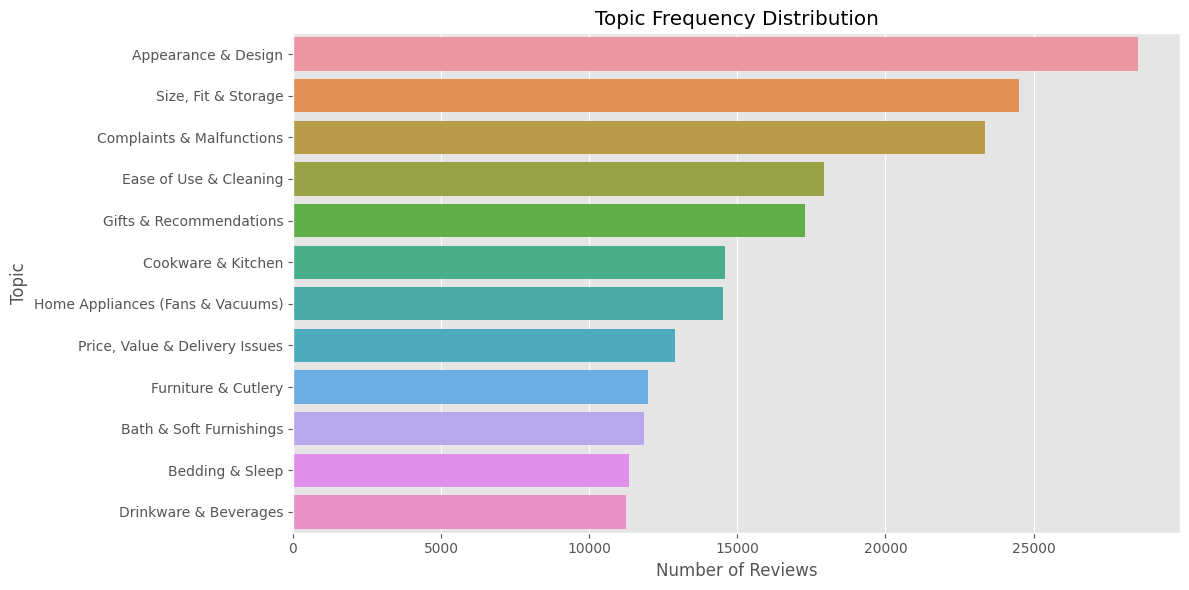

In [216]:
# Визуализируем распределение тем
plt.figure(figsize=(12, 6))

sns.barplot(
    data=topic_frequency_df,
    x="count",
    y="topic_label"
)

plt.title("Topic Frequency Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

In [217]:
topic_sentiment = pd.crosstab(
    reviews["topic_label"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

topic_sentiment.round(2)

sentiment_label,negative,neutral,positive
topic_label,,,
Appearance & Design,3.41,4.26,92.33
Bath & Soft Furnishings,5.93,6.08,87.99
Bedding & Sleep,14.62,7.27,78.12
Complaints & Malfunctions,34.07,20.81,45.12
Cookware & Kitchen,5.04,4.66,90.30
Drinkware & Beverages,5.38,4.29,90.34
Ease of Use & Cleaning,3.39,3.02,93.59
Furniture & Cutlery,11.12,11.49,77.39
Gifts & Recommendations,0.63,0.93,98.44


> Доли тональности по темам ниже рассчитаны на воспроизводимой подвыборке 200k отзывов (`reviews.sample(200_000)`), на которой обучалась LDA, а не на всём датасете.

Topic-sentiment analysis показывает, что customer topics сильно различаются по распределению тональности.

Самые проблемные темы:
- `Price, Value & Delivery Issues` — `41.8%` negative и лишь `48.6%` positive (жалобы на цену/ценность, дешёвый материал, проблемы с доставкой и упаковкой);
- `Complaints & Malfunctions` — `34.1%` negative и самый высокий уровень `neutral` (`20.8%`); это тема отзывов с отрицанием (`does not work`, `did not`), где товар не оправдал ожиданий.

Самые позитивные темы (`>92%` positive): `Gifts & Recommendations` (`98.4%`), `Size, Fit & Storage` (`93.7%`), `Ease of Use & Cleaning` (`93.6%`), `Appearance & Design` (`92.3%`).

То есть негатив концентрируется не вокруг конкретной товарной категории, а вокруг тем «цена / ценность / доставка» и «поломки / несоответствие ожиданиям» — это и есть основные customer pain points. Объединение topic modeling и sentiment analysis позволяет точечно их локализовать.

### Topic Trends Over Time

Анализ динамики тем по времени позволяет определить изменение customer interests и product-related discussions в разные периоды времени.

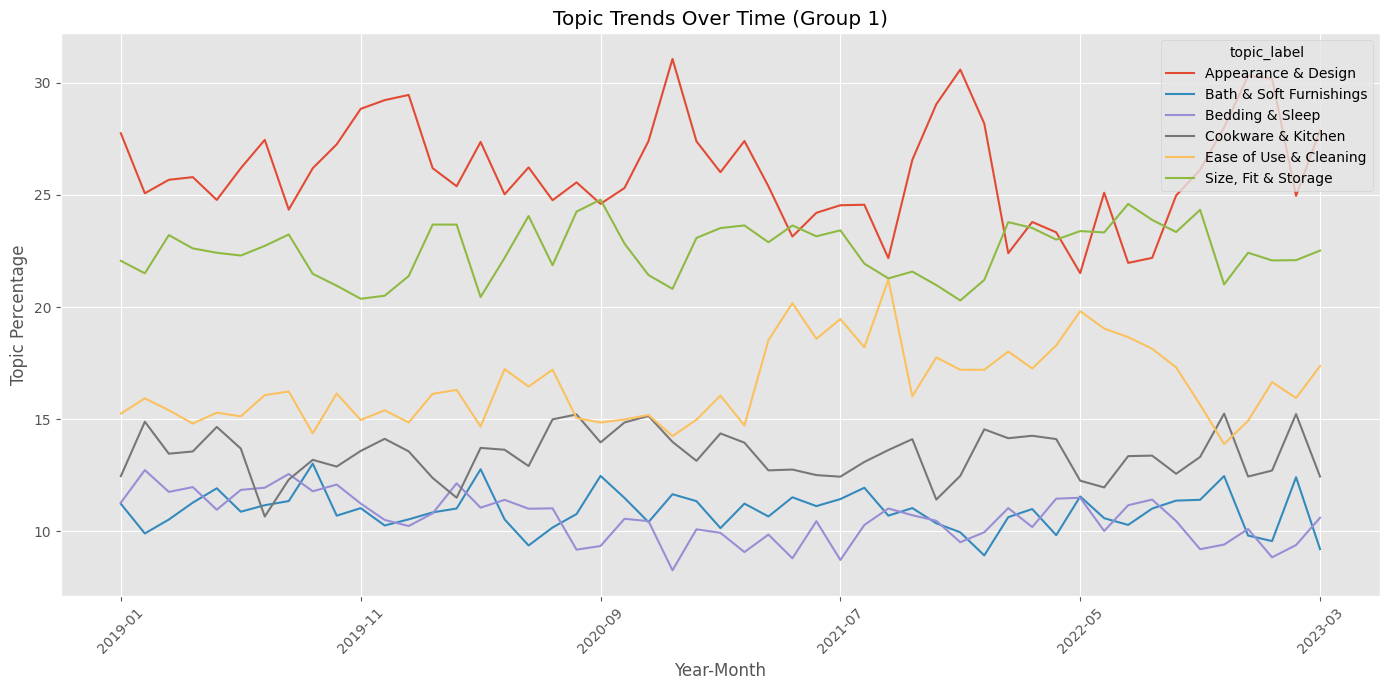

In [218]:
# Получаем список тем
topics = reviews["topic_label"].dropna().unique()

# Первые 6 тем
topics_group_1 = topics[:6]

# Фильтруем DataFrame
reviews_group_1 = reviews[
    reviews["topic_label"].isin(topics_group_1)
]

# Нормализованное распределение тем по времени
topic_time_group_1 = pd.crosstab(
    reviews_group_1["year_month"],
    reviews_group_1["topic_label"],
    normalize="index"
) * 100

# Визуализация
topic_time_group_1.plot(
    figsize=(14, 7)
)

plt.title("Topic Trends Over Time (Group 1)")
plt.xlabel("Year-Month")
plt.ylabel("Topic Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

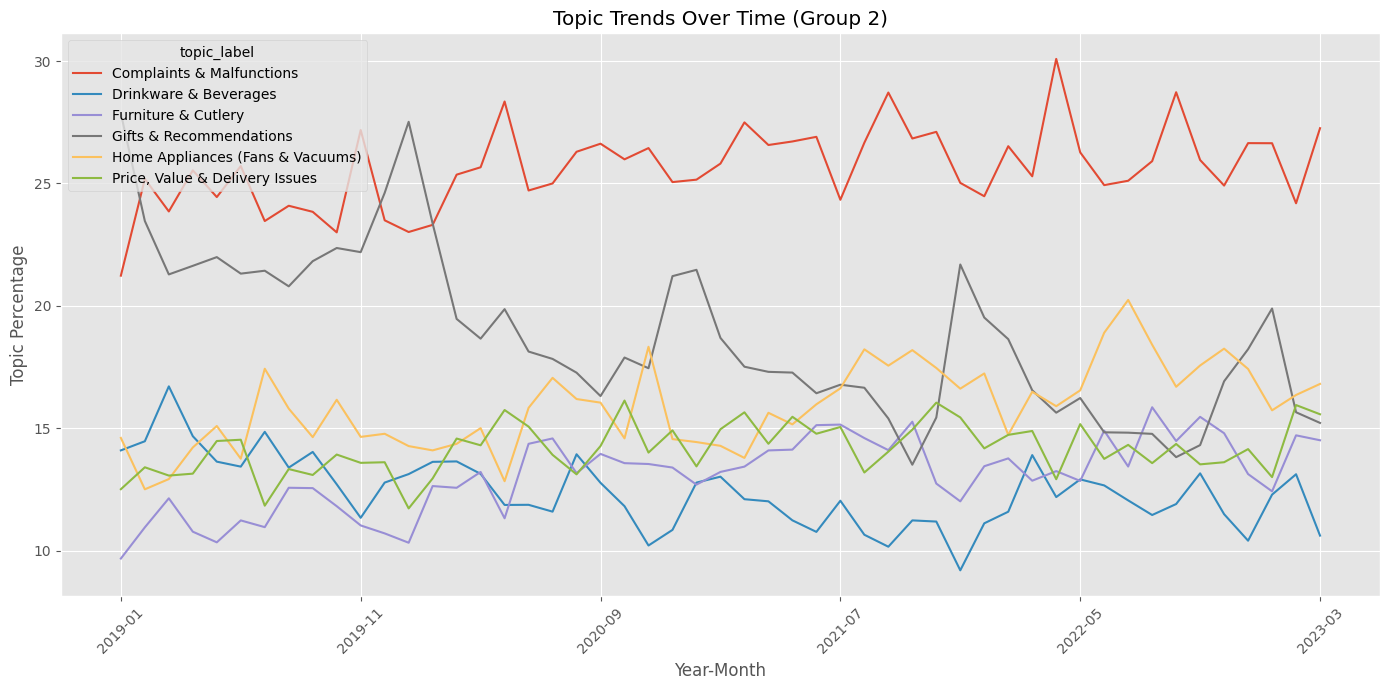

In [219]:
# Вторые 6 тем
topics_group_2 = topics[6:]

# Фильтруем DataFrame
reviews_group_2 = reviews[
    reviews["topic_label"].isin(topics_group_2)
]

# Нормализованное распределение тем по времени
topic_time_group_2 = pd.crosstab(
    reviews_group_2["year_month"],
    reviews_group_2["topic_label"],
    normalize="index"
) * 100

# Визуализация
topic_time_group_2.plot(
    figsize=(14, 7)
)

plt.title("Topic Trends Over Time (Group 2)")
plt.xlabel("Year-Month")
plt.ylabel("Topic Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

LDA выделил 12 устойчивых customer topics в отзывах Amazon Home & Kitchen — от товарных категорий (`Bedding & Sleep`, `Cookware & Kitchen`, `Drinkware & Beverages`, `Bath & Soft Furnishings`, `Home Appliances`, `Furniture & Cutlery`) до сквозных тем пользовательского опыта (`Ease of Use & Cleaning`, `Appearance & Design`, `Size, Fit & Storage`, `Gifts & Recommendations`) и проблемных тем (`Price, Value & Delivery Issues`, `Complaints & Malfunctions`).

Topic-sentiment analysis показал, что наиболее негативные темы — `Price, Value & Delivery Issues` (`41.8%` negative) и `Complaints & Malfunctions` (`34.1%` negative), тогда как `Gifts & Recommendations` и `Ease of Use & Cleaning` имеют почти полностью позитивную тональность (`>93%`).

Topic trends over time показывают, что распределение тем во времени в целом стабильно, с умеренными колебаниями долей отдельных тем по месяцам.

Примечание: темы и доли тональности рассчитаны на воспроизводимой подвыборке 200k отзывов, на которой обучалась LDA. Индексы тем LDA не стабильны между переобучениями — бизнес-метки сопоставлены вручную по топ-словам (`print_topics`), и при повторном обучении модели их нужно перепроверить.

## 7. Sentiment-Rating Mismatch Analysis

In [220]:
# Mismatch-анализ ведём на ФИНАЛЬНОЙ (деплой-) модели — calibrated LinearSVC,
# чтобы выводы относились к продакшен-модели, а не к baseline Logistic Regression.
final_model = pipe_svc

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)
confidence_final = y_proba_final.max(axis=1)

final_predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_final,
    "confidence": confidence_final,
    "rating": reviews.loc[X_test.index, "rating"].values
})

final_predictions_df.head()

,text,true_label,predicted_label,confidence,rating
0,i love it i bought this because it is pretty and the green one reminds me of my parrot it looks like the picture,positive,positive,0.923807,5
1,good size cute and durable i originally ordered the goose one liked it so much i ordered the fox it is a perfect sized coffee cup i can put abut 12 1 2 oz coffee or tea in comfortably it has a sle...,positive,positive,0.984789,5
2,you get what you pay for not that bad though if you just need an extra cover for a guest room or something this is perfect it s cheap and simple but the size is a little larger than it should be b...,neutral,positive,0.600742,3
3,wow so much more than i anticipated while this may appear like a fancy update on a beanbag style chair it is so much more than that this low sitting chair will quickly become a favorite for people...,positive,positive,0.969575,5
4,great no slip treads easy to adhere to a clean surface used alcohol on the surface as implied in instructions have been in place through numerous baths and showers with no problem,positive,positive,0.958894,5


In [221]:
# Порог уверенности модели.
# predicted_label — это лишь ОЦЕНКА тональности (macro-F1 ~ 0.66), поэтому случай
# "5 звёзд + negative" может быть как реальным расхождением рейтинга и текста,
# так и просто ошибкой модели. Отсекая низкоуверенные предсказания, мы оставляем
# более правдоподобные mismatch-кейсы и не выдаём шум модели за инсайт.
CONFIDENCE_THRESHOLD = 0.70

In [222]:
# Распределение confidence по тестовой выборке
final_predictions_df["confidence"].describe()

count    92140.000000
mean         0.885842
std          0.146015
min          0.334856
25%          0.855264
50%          0.952817
75%          0.981481
max          0.999862
Name: confidence, dtype: float64

In [223]:
# 5 звёзд + предсказан negative
mismatch_5_negative = final_predictions_df[
    (final_predictions_df["rating"] == 5) &
    (final_predictions_df["predicted_label"] == "negative")
]

# High-confidence подмножество: вероятные mismatch, а не ошибки модели
mismatch_5_negative_hc = mismatch_5_negative[
    mismatch_5_negative["confidence"] >= CONFIDENCE_THRESHOLD
]

mismatch_5_negative_hc.head(30)

,text,true_label,predicted_label,confidence,rating
490,not for home grown i rarely give bad reviews and i am not starting now i am sure as most on here say it is dandy for carbon copy el perecto hothouse tomatoes however for home grown i found it pret...,positive,negative,0.752743,5
667,zipper broke and ripped putting it on good but the zipper broke and ripped in couple of spots and put it on where it was so together,positive,negative,0.749352,5
1077,works update after not even 2 years update the seals break and it leaks i got a new one from a different brand and found out it had not been working for a whole just spend 50 more with someone els...,positive,negative,0.702463,5
3997,sheets they are terrible after a wash they look faded they don t stay tight to the bed terrible sheets,positive,negative,0.824787,5
5957,look good but do not hold up these broke within 2 months they need to be made out of metal,positive,negative,0.750402,5
6490,not genuine real turquoise not real turquoise very disappointed in what i got,positive,negative,0.915020,5
6517,disappointed these do not stay closed so you have to tape them closed disappointing,positive,negative,0.835833,5
7920,fairy tree very cheap looking when you get item looks so much better in picture workman ship not there,positive,negative,0.803742,5
9813,1st impression is not for long i washed it and it lost it is durability,positive,negative,0.756556,5
10372,will not stay in place updated review the chair has an issue when you tilt it back it will not stay in place you sit down and it snaps forward not every time but 2 3 times a day i would not recomm...,positive,negative,0.754534,5


In [224]:
# Количество 5-star negative mismatches: все и high-confidence
five_star_total = int((final_predictions_df["rating"] == 5).sum())

print(
    f"5* + negative (все): {len(mismatch_5_negative)} "
    f"({len(mismatch_5_negative) / five_star_total * 100:.2f}% всех 5*)"
)
print(
    f"5* + negative (confidence >= {CONFIDENCE_THRESHOLD}): "
    f"{len(mismatch_5_negative_hc)} "
    f"({len(mismatch_5_negative_hc) / five_star_total * 100:.2f}% всех 5*)"
)

5* + negative (все): 309 (0.49% всех 5*)
5* + negative (confidence >= 0.7): 89 (0.14% всех 5*)


In [225]:
# 1 звезда + предсказан positive
mismatch_1_positive = final_predictions_df[
    (final_predictions_df["rating"] == 1) &
    (final_predictions_df["predicted_label"] == "positive")
]

# High-confidence подмножество
mismatch_1_positive_hc = mismatch_1_positive[
    mismatch_1_positive["confidence"] >= CONFIDENCE_THRESHOLD
]

mismatch_1_positive_hc.head(30)

,text,true_label,predicted_label,confidence,rating
432,sheds white balls each and every time i wash this couch cover it sheds small white balls from the underneath gripping part that helps to hold it in place this is so aggravating other than that i l...,negative,positive,0.853994,1
1037,attractive look only pendulum works the pendulum works fine click hands do not move not happy with product fresh batteries were inserted correctly,negative,positive,0.782385,1
1693,it is an inch and a half tall make sure to read the description its an inch and a half tall this is not a full sized chalice though perhaps nice for a tea party,negative,positive,0.702595,1
1765,not worth it i could not tell one bit of difference with these after 2 weeks of use they re easy to plug into the outlets and completely quiet but nothing was fresher,negative,positive,0.824723,1
3537,very disappointed i hate having to change my review from five stars down to one the set is beautiful i couldn t have been more happy with it when i received it and it is fluffy and soft and i ve g...,negative,positive,0.709161,1
3553,not stainless steel like others say here sold it as stainless steel did a magnetic test and it clearly shows the units are metal and not stainless steel,negative,positive,0.734876,1
3671,water keeps getting into battery compartment others kept saying this would happen true enough,negative,positive,0.752448,1
4891,ugly these are easy to install and super stretchy but the fabric is chunky hot and super casual,negative,positive,0.735909,1
5742,needs to be packed not just sat down in a box i know i will love it but it arrived in a thousand pieces,negative,positive,0.838386,1
6241,turns your kitchen knives into butter knifes i was a chef back in the day i owned my own set of henckel knives custom sharpened and the handles wrapped with wax and jute also i owned my own set of...,negative,positive,0.932637,1


In [226]:
# Количество 1-star positive mismatches: все и high-confidence
one_star_total = int((final_predictions_df["rating"] == 1).sum())

print(
    f"1* + positive (все): {len(mismatch_1_positive)} "
    f"({len(mismatch_1_positive) / one_star_total * 100:.2f}% всех 1*)"
)
print(
    f"1* + positive (confidence >= {CONFIDENCE_THRESHOLD}): "
    f"{len(mismatch_1_positive_hc)} "
    f"({len(mismatch_1_positive_hc) / one_star_total * 100:.2f}% всех 1*)"
)

1* + positive (все): 713 (11.29% всех 1*)
1* + positive (confidence >= 0.7): 200 (3.17% всех 1*)


In [227]:
# Средний confidence для mismatch cases
print(
    f"Средний confidence (5* + negative): "
    f"{mismatch_5_negative['confidence'].mean():.2f}"
)

print(
    f"Средний confidence (1* + positive): "
    f"{mismatch_1_positive['confidence'].mean():.2f}"
)

Средний confidence (5* + negative): 0.61
Средний confidence (1* + positive): 0.62


Mismatch analysis сравнивает звёздный рейтинг с тональностью, предсказанной финальной моделью (calibrated LinearSVC). Важно: `predicted_label` — это оценка модели, поэтому расхождение может быть как реальным (текст ≠ рейтинг), так и ошибкой модели. Чтобы отделить одно от другого, дополнительно смотрим high-confidence подмножество (`confidence ≥ 0.70`).

В тестовой выборке (92 140 отзывов):
- `5★ + negative`: `309` случаев (`0.49%` всех 5★); из них высокоуверенных — `89` (`0.14%`).
- `1★ + positive`: `713` случаев (`11.29%` всех 1★); из них высокоуверенных — `200` (`3.17%`).

Средний confidence по обоим типам — `0.61–0.62`, то есть многие mismatch-кейсы пограничны: фильтр по уверенности отсекает ~70% из них как вероятные ошибки модели.

Несимметрия показательна: «1★ + positive» встречается заметно чаще, чем «5★ + negative» — модель смещена в сторону `positive` (доминирующий класс), а часть низких рейтингов содержит спокойно-описательный или частично положительный текст. Реальные (high-confidence) расхождения подтверждают ограничения weak supervision: отзывы содержат mixed sentiment, а низкие рейтинги нередко связаны с доставкой/упаковкой, а не с самим товаром.

## 8. Insight Fusion Layer

### Most Negative Topics

Анализ наиболее негативных customer topics позволяет определить product categories и customer pain points с самым высоким уровнем dissatisfaction.

In [228]:
# Процент negative reviews по темам
negative_topic_share = pd.crosstab(
    reviews["topic_label"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

In [229]:
# Оставляем только negative sentiment
negative_topic_share = negative_topic_share[
    ["negative"]
].sort_values(
    by="negative",
    ascending=False
)

negative_topic_share.round(2)

sentiment_label,negative
topic_label,
"Price, Value & Delivery Issues",41.79
Complaints & Malfunctions,34.07
Bedding & Sleep,14.62
Home Appliances (Fans & Vacuums),11.98
Furniture & Cutlery,11.12
Bath & Soft Furnishings,5.93
Drinkware & Beverages,5.38
Cookware & Kitchen,5.04
Appearance & Design,3.41


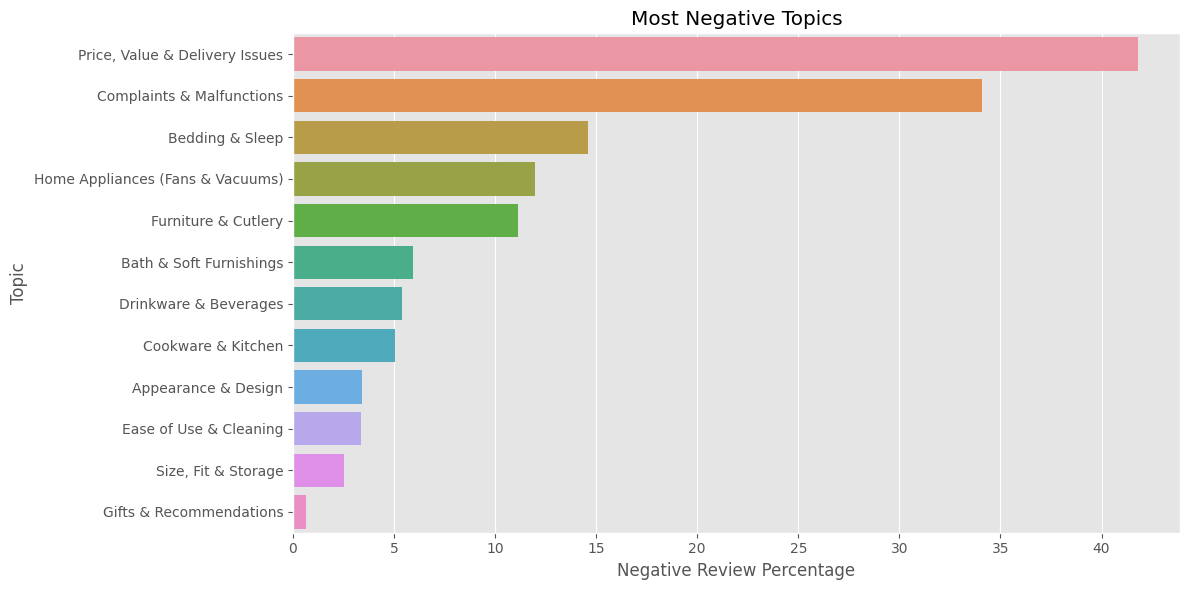

In [230]:
# Визуализируем самые негативные темы
plt.figure(figsize=(12, 6))

sns.barplot(
    data=negative_topic_share.reset_index(),
    x="negative",
    y="topic_label"
)

plt.title("Most Negative Topics")
plt.xlabel("Negative Review Percentage")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Helpful Votes by Topic

Helpful votes analysis показывает, какие customer topics вызывают наибольший отклик и вовлеченность пользователей.

In [231]:
# Среднее количество helpful votes по темам
helpful_by_topic = reviews.groupby(
    "topic_label"
)["helpful_vote"].mean().sort_values(
    ascending=False
)

helpful_by_topic.round(2)

topic_label
Home Appliances (Fans & Vacuums)    1.58
Furniture & Cutlery                 1.32
Bedding & Sleep                     1.30
Complaints & Malfunctions           1.28
Cookware & Kitchen                  1.21
Price, Value & Delivery Issues      0.93
Drinkware & Beverages               0.93
Ease of Use & Cleaning              0.80
Bath & Soft Furnishings             0.78
Size, Fit & Storage                 0.59
Appearance & Design                 0.55
Gifts & Recommendations             0.39
Name: helpful_vote, dtype: float64

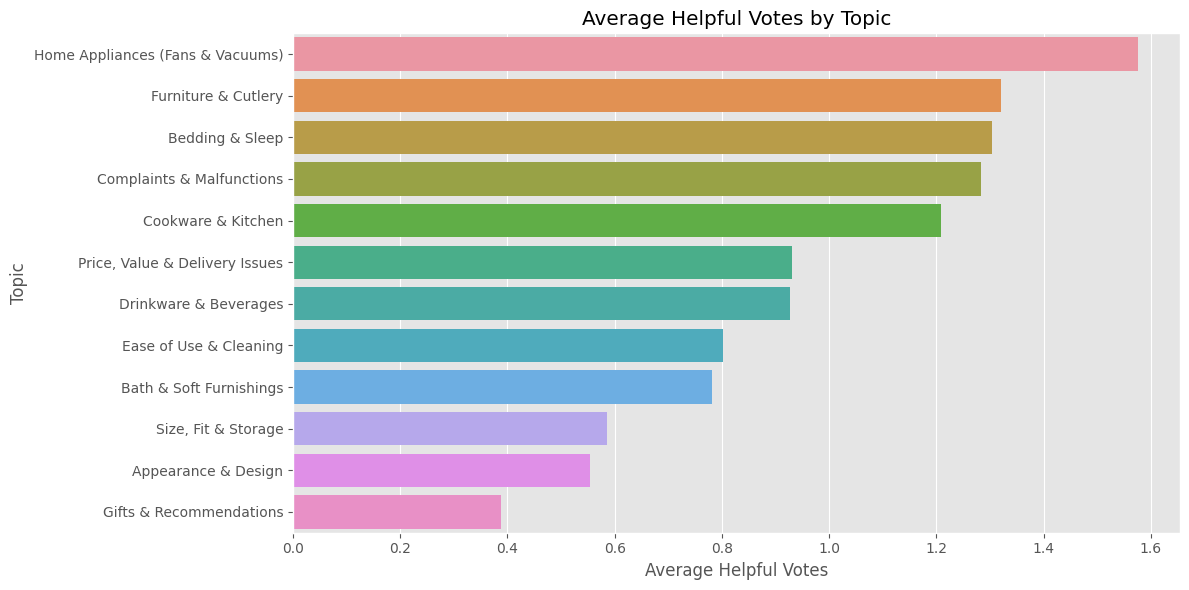

In [232]:
# Визуализируем helpful votes по темам
plt.figure(figsize=(12, 6))

sns.barplot(
    x=helpful_by_topic.values,
    y=helpful_by_topic.index
)

plt.title("Average Helpful Votes by Topic")
plt.xlabel("Average Helpful Votes")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

Helpful votes analysis показал, что customer engagement заметно различается между темами.

Больше всего helpful votes в среднем набирают темы `Home Appliances (Fans & Vacuums)` (`1.58`), `Furniture & Cutlery` (`1.32`), `Bedding & Sleep` (`1.30`), `Complaints & Malfunctions` (`1.28`) и `Cookware & Kitchen` (`1.21`). Это технически сложные/дорогие товары и проблемные отзывы: отзывы с практическими деталями и описанием проблем воспринимаются другими покупателями как наиболее полезные.

Меньше всего откликов получают темы `Gifts & Recommendations` (`0.39`), `Appearance & Design` (`0.55`) и `Size, Fit & Storage` (`0.59`) — как правило, более короткие и эмоциональные отзывы.

Результаты подтверждают, что problem-focused и practical reviews вызывают более высокий customer engagement.

### Verified Purchase Analysis by Topic

Анализ verified purchases по темам позволяет определить, какие customer topics чаще встречаются у подтвержденных покупателей.

In [233]:
verified_by_topic = pd.crosstab(
    reviews["topic_label"],
    reviews["verified_purchase"],
    normalize="index"
) * 100

In [234]:
verified_by_topic = verified_by_topic.rename(
    columns={
        True: "verified",
        False: "non_verified"
    }
)

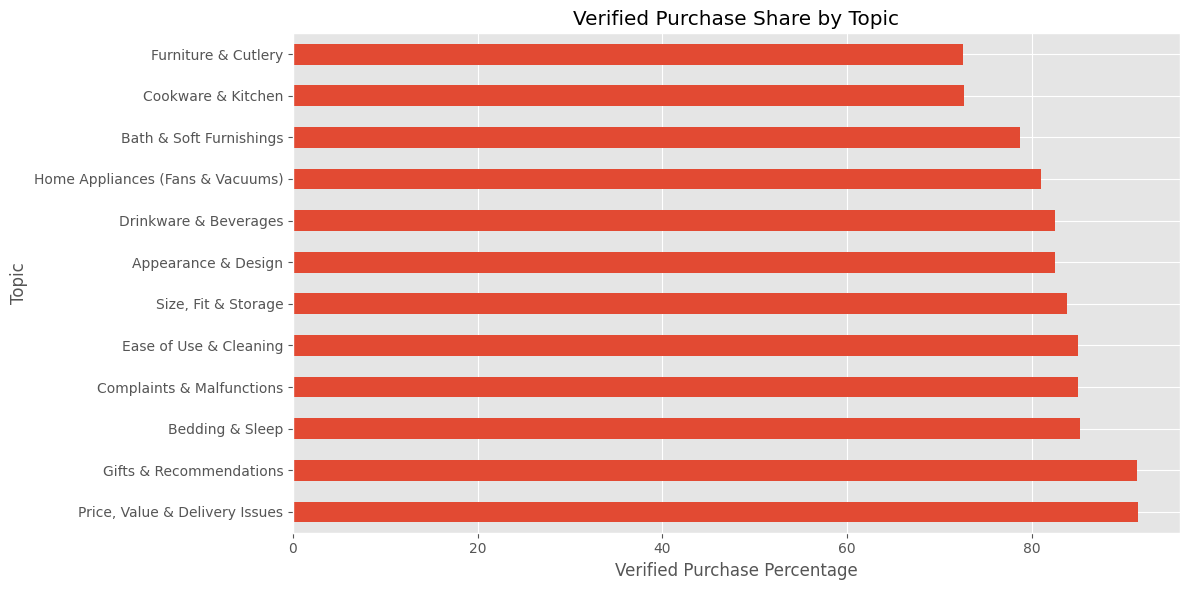

In [235]:
# Визуализируем verified purchases по темам
verified_by_topic["verified"].sort_values(
    ascending=False
).plot(
    kind="barh",
    figsize=(12, 6)
)

plt.title("Verified Purchase Share by Topic")
plt.xlabel("Verified Purchase Percentage")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Sentiment Trends Over Time

Анализ динамики sentiment-классов по времени позволяет определить изменение customer satisfaction и review behavior в разные периоды времени.

In [236]:
# Нормализованное распределение sentiment по времени
sentiment_time = pd.crosstab(
    reviews["year_month"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

sentiment_time.head()

sentiment_label,negative,neutral,positive
year_month,,,
2019-01,9.702755,6.222813,84.074432
2019-02,10.740494,6.187458,83.072048
2019-03,10.425532,6.921986,82.652482
2019-04,10.188438,6.898754,82.912807
2019-05,10.010381,6.525285,83.464333


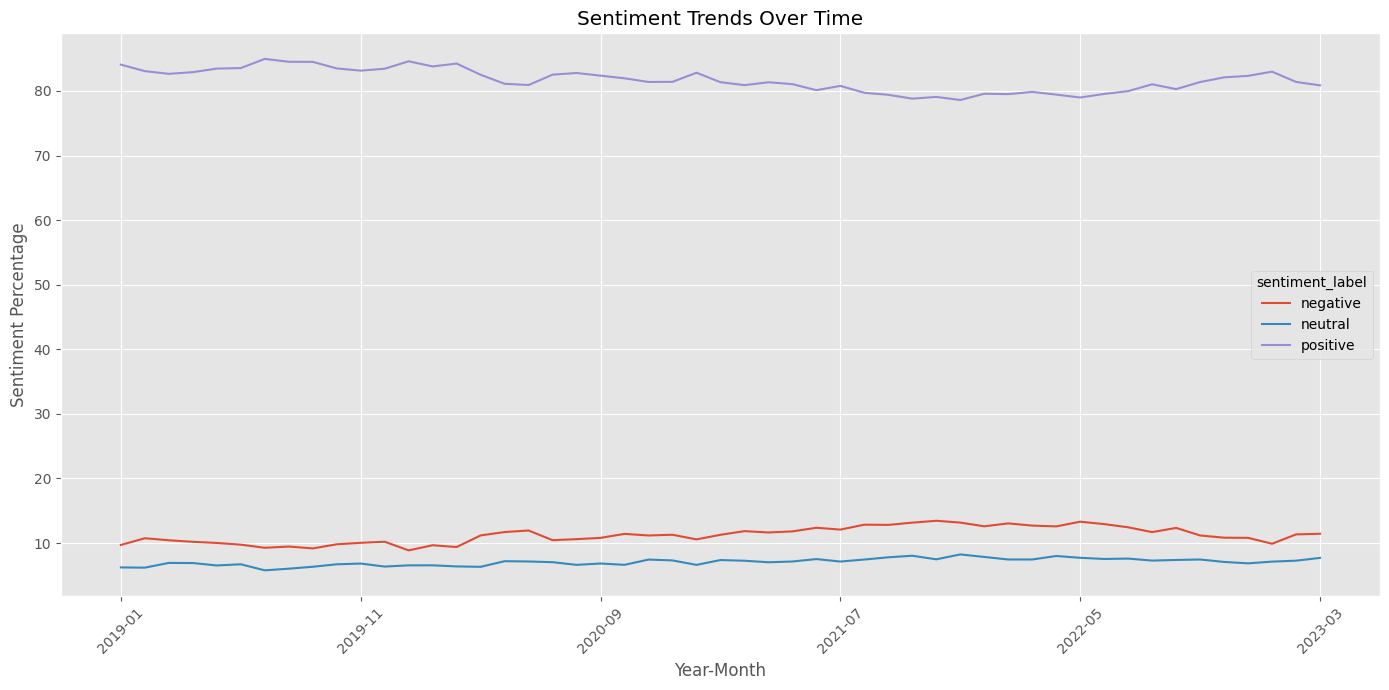

In [237]:
# Визуализируем sentiment trends over time
sentiment_time.plot(
    figsize=(14, 7)
)

plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Sentiment Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight Fusion Layer объединил результаты sentiment analysis, topic modeling и customer metadata.

- **Topic-level sentiment:** наиболее проблемные темы — `Price, Value & Delivery Issues` (`41.8%` negative) и `Complaints & Malfunctions` (`34.1%` negative); самые удовлетворённые — `Gifts & Recommendations` и `Ease of Use & Cleaning` (`>93%` positive).
- **Helpful votes:** наибольший engagement у `Home Appliances`, `Furniture & Cutlery`, `Bedding & Sleep` и проблемных отзывов (`Complaints & Malfunctions`) — практические и problem-focused reviews ценнее для пользователей.
- **Verified purchase:** доли подтверждённых покупок различаются между темами.
- **Temporal analytics:** распределение sentiment во времени стабильно, с устойчивым доминированием `positive` (~82%).

Связка тем и тональности позволяет точечно находить customer pain points (цена/ценность/доставка, поломки и несоответствие ожиданиям) и приоритизировать улучшения товара и сервиса.

## 9. Final Dashboard Section

### Topic-Sentiment Heatmap

Heatmap позволяет визуализировать распределение sentiment-классов внутри customer topics и определить наиболее проблемные product categories.

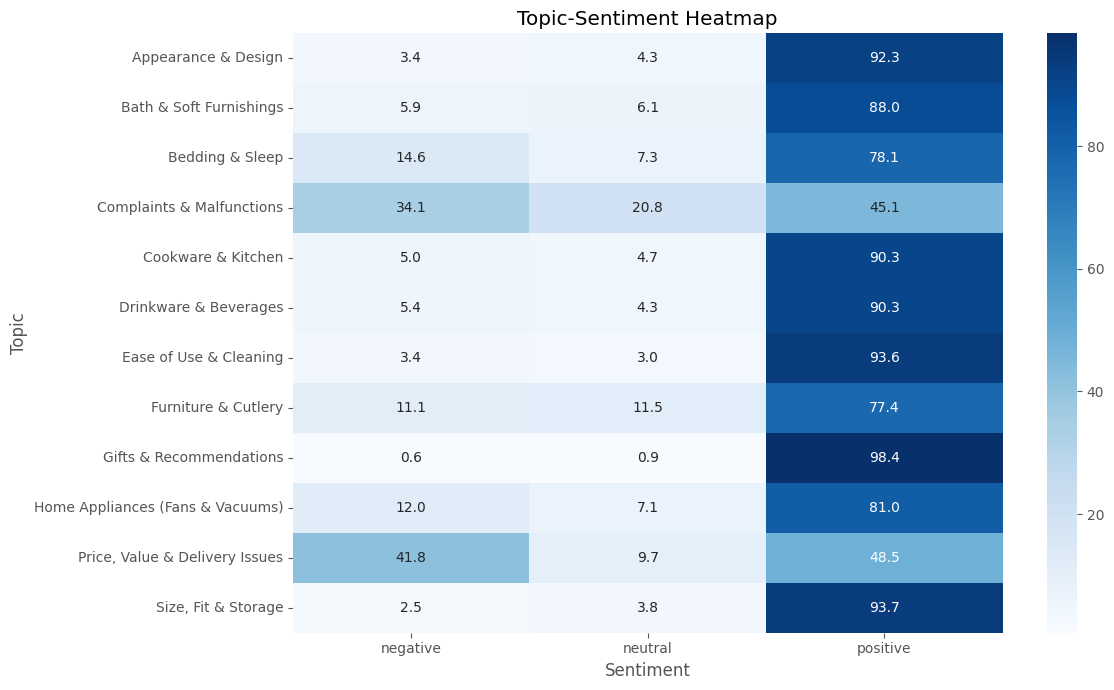

In [238]:
# Визуализируем распределение sentiment по темам
plt.figure(figsize=(12, 7))

sns.heatmap(
    topic_sentiment,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Topic-Sentiment Heatmap")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Most Negative Topics

Barplot показывает customer topics с самым высоким уровнем negative sentiment и помогает выявить основные customer pain points.

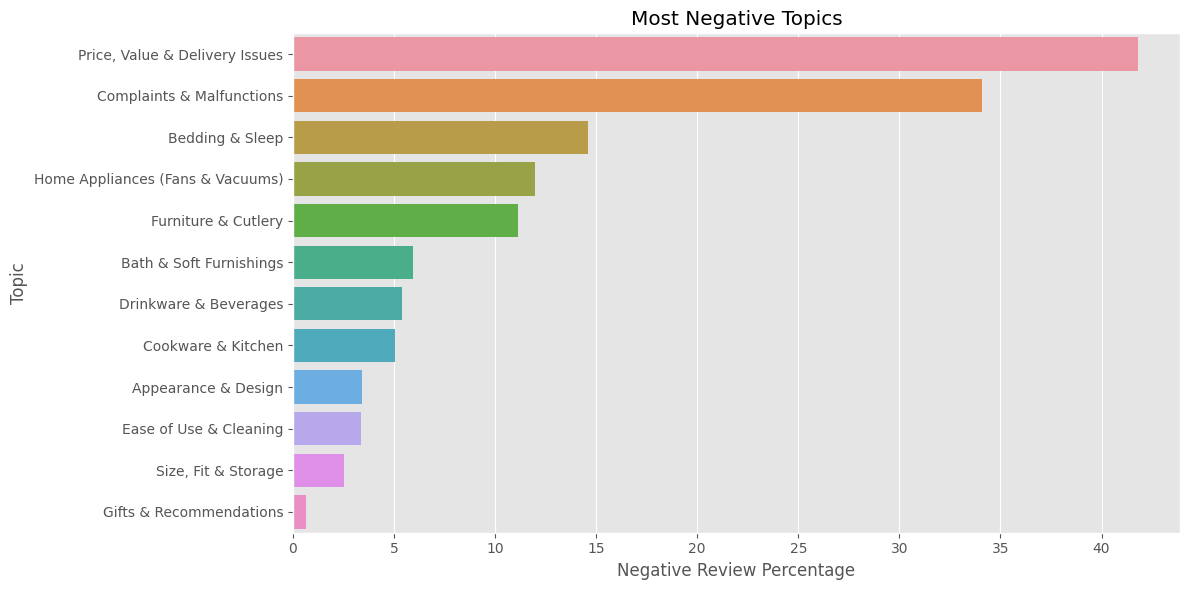

In [239]:
# Визуализируем самые негативные темы
plt.figure(figsize=(12, 6))

sns.barplot(
    data=negative_topic_share.reset_index(),
    x="negative",
    y="topic_label"
)

plt.title("Most Negative Topics")
plt.xlabel("Negative Review Percentage")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Sentiment Trends Over Time

Time-series visualization показывает изменение распределения sentiment-классов во времени и динамику customer satisfaction.

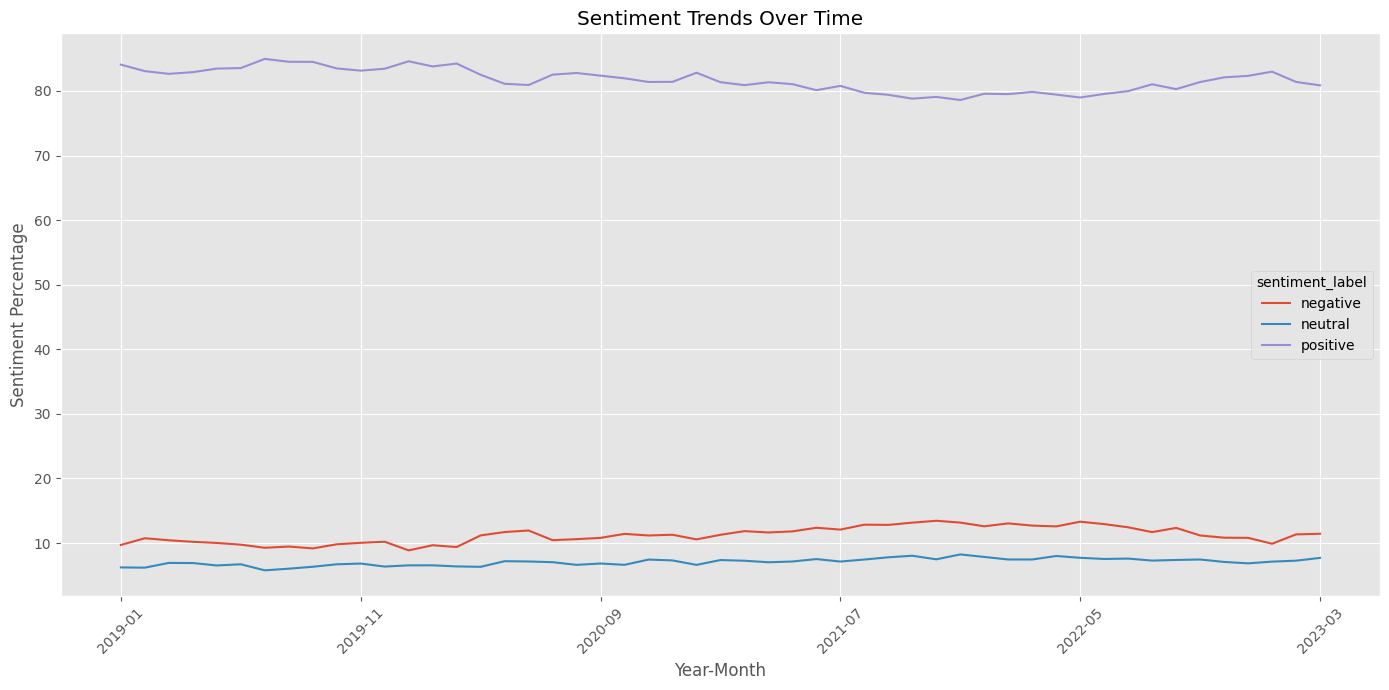

In [240]:
# Визуализируем sentiment trends over time
sentiment_time.plot(
    figsize=(14, 7)
)

plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Sentiment Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Deployment

Финальная модель собирается как **end-to-end Pipeline**: `сырой текст → очистка → calibrated LinearSVC → sentiment`. Шаг очистки (`FunctionTransformer` поверх `clean_review_text`) встроен в сам Pipeline, поэтому модель принимает необработанный отзыв (с HTML и contractions) и сама приводит его к тому же виду, что и при обучении. Это исключает рассинхрон train/inference препроцессинга.

Модель сохраняется в `models/final_sentiment_model.joblib`, загружается обратно и проверяется на сырых примерах (positive и negative) — оба предсказания корректны.

**Возможное развитие:** интерактивный Streamlit-дашборд (sentiment prediction, topic exploration, business analytics) поверх сохранённых артефактов — пока не реализован, вынесен как следующий шаг.

In [241]:
# Финальная модель для деплоя: оборачиваем обученный pipe_svc в Pipeline
# с шагом очистки текста, чтобы модель принимала СЫРОЙ текст (HTML, contractions и т.д.)
# Это исключает рассинхронизацию между training-time и inference-time препроцессингом.

def clean_batch(texts):
    return [clean_review_text(t) for t in texts]

final_sentiment_model = Pipeline([
    ("clean", FunctionTransformer(clean_batch, validate=False)),
    ("model", pipe_svc),
])

joblib.dump(
    final_sentiment_model,
    "models/final_sentiment_model.joblib"
)

print("Final model saved (end-to-end: raw text -> sentiment)")


Final model saved (end-to-end: raw text -> sentiment)


In [242]:
# Загружаем сохраненную модель
loaded_model = joblib.load(
    "models/final_sentiment_model.joblib"
)

print("Model loaded successfully")

Model loaded successfully


In [243]:
# Пример предсказания на СЫРОМ тексте (с HTML и contractions)
sample_review = "The product <b>looks great</b> and it's very easy to use!!! https://amazon.com"

prediction = loaded_model.predict([sample_review])

print(f"Predicted sentiment: {prediction[0]}")


Predicted sentiment: positive


In [244]:
# Пример negative review с contractions и HTML
negative_review = "The product stopped working after two days and doesn't feel sturdy. I can't recommend it."

negative_prediction = loaded_model.predict([negative_review])

print(f"Negative review prediction: {negative_prediction[0]}")


Negative review prediction: negative


## 11. Подбор гиперпараметров baseline (LinearSVC)

LinearSVC показал лучшие результаты среди baseline-моделей, поэтому следующим шагом выполним подбор гиперпараметров с помощью `RandomizedSearchCV`.

Оптимизация проводится по метрике **macro F1-score**, которая лучше подходит для несбалансированных данных. Подбираются как параметры самой модели, так и параметры TF-IDF-векторизации. Для оценки используется 3-fold кросс-валидация.

Лучшая найденная модель сохраняется на диск и повторно загружается при следующих запусках ноутбука.

Tuned LinearSVC loaded
              precision    recall  f1-score   support

    negative      0.735     0.785     0.759     10332
     neutral      0.407     0.464     0.434      6505
    positive      0.969     0.948     0.959     75303

    accuracy                          0.896     92140
   macro avg      0.704     0.732     0.717     92140
weighted avg      0.903     0.896     0.899     92140



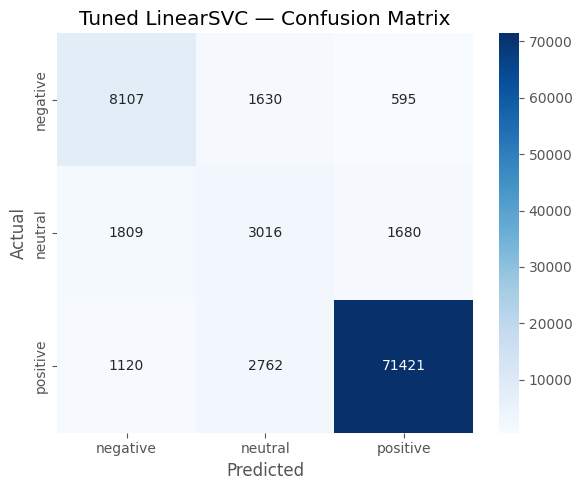

In [245]:
# Подбор гиперпараметров LinearSVC и TF-IDF по macro-F1
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

svc_tuned_path = "models/svc_tuned_pipeline.joblib"

# Тот же вход и split, что у baseline: X_train / X_test = clean_text.
pipe_tuned = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("clf", LinearSVC(class_weight="balanced", random_state=42)),
    ]
)

if os.path.exists(svc_tuned_path):
    pipe_tuned = joblib.load(svc_tuned_path)
    print("Tuned LinearSVC loaded")
else:
    param_dist = {
        "tfidf__max_features": [20000, 50000, 100000],
        "tfidf__min_df": [2, 5, 10],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "clf__C": loguniform(1e-2, 1e1),
    }
    search = RandomizedSearchCV(
        pipe_tuned,
        param_dist,
        n_iter=15,
        scoring="f1_macro",
        cv=3,
        n_jobs=4,
        random_state=42,
        verbose=1,
    )
    search.fit(X_train, y_train)
    print("Best params:", search.best_params_)
    print("Best CV macro-F1:", round(search.best_score_, 4))

    # Рефит лучшей конфигурации на ПОЛНОМ train.
    pipe_tuned = Pipeline(
        [
            ("tfidf", TfidfVectorizer()),
            ("clf", LinearSVC(class_weight="balanced", random_state=42)),
        ]
    ).set_params(**search.best_params_)
    pipe_tuned.fit(X_train, y_train)
    joblib.dump(pipe_tuned, svc_tuned_path)
    print("Tuned LinearSVC trained and saved")

# Оценка на тестовой выборке
y_pred_tuned = pipe_tuned.predict(X_test)
print(classification_report(y_test, y_pred_tuned, digits=3))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"],
)
plt.title("Tuned LinearSVC — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Результат подбора

| LinearSVC | Accuracy | Macro F1 | Weighted F1 | Recall (neutral) |
|---|---|---|---|---|
| Параметры по умолчанию (`C=1.0`) | 0.901 | 0.657 | 0.886 | 0.170 |
| **После подбора** (`C≈0.06`, TF-IDF 50k, uni+bi) | 0.896 | **0.717** | **0.899** | **0.464** |

Подбор гиперпараметров существенно улучшил качество модели. Несмотря на небольшое снижение accuracy (`0.901 → 0.896`), удалось добиться значительного роста качества на всех классах в целом:

- **Macro F1-score** вырос с `0.657` до `0.717`, что является самым заметным улучшением среди всех рассмотренных экспериментов.
- **Weighted F1-score** также увеличился (`0.886 → 0.899`), что говорит о сохранении высокого качества на доминирующем классе `positive`.
- **Recall класса `neutral`** вырос почти в три раза (`0.17 → 0.46`), что существенно сократило главный недостаток базовой версии LinearSVC.

Ключевую роль сыграл параметр регуляризации `C`. Оптимальное значение оказалось значительно меньше стандартного (`C ≈ 0.06` против `C = 1.0`). Более сильная регуляризация в сочетании с `class_weight="balanced"` позволила модели уделять больше внимания редким классам и уменьшить смещение в сторону класса `positive`.

Снижение accuracy в данном случае является ожидаемым и приемлемым компромиссом. На несбалансированном датасете эта метрика в значительной степени определяется качеством на классе `positive`, поэтому небольшая потеря общей точности компенсируется заметным ростом качества на менее представленных классах.

#### Вывод

Результаты показывают, что потенциал классических линейных моделей значительно выше, чем может показаться при использовании параметров по умолчанию. После настройки гиперпараметров LinearSVC не только сохранил высокое качество на классе `positive`, но и существенно улучшил распознавание класса `neutral`.

С итоговым **Macro F1 = 0.717** и **Weighted F1 = 0.899** настроенный LinearSVC становится лучшей baseline-моделью в проекте и задаёт сильную точку отсчёта для последующего сравнения с трансформерными архитектурами.

Остаётся проверить, сможет ли модель, учитывающая контекст слов и порядок их появления в тексте, превзойти этот результат. Этому посвящён следующий эксперимент с DistilBERT.

## 12. Experiment: Transformer (DistilBERT)

Baseline-модели на TF-IDF показали хорошие результаты по общим метрикам, однако их основное ограничение остаётся неизменным — они работают с набором слов и не учитывают полноценный контекст предложения. Наиболее заметно это проявляется на классе `neutral`, который оказался самым сложным для классификации.

В данном эксперименте проверяем, способен ли контекстный трансформер DistilBERT улучшить качество классификации по сравнению с classical ML baseline.

Для корректного сравнения используются:
- тот же `train_test_split` (`random_state=42`, stratify);
- та же схема разметки: `1–2 → negative`, `3 → neutral`, `4–5 → positive`;
- та же тестовая выборка.

Ключевые отличия DistilBERT:
- работает с исходным текстом (`title + text`) без TF-IDF-преобразования;
- учитывает контекст слов и структуру предложения;
- использует взвешенный loss для частичной компенсации сильного дисбаланса классов (~82/11/7);
- обучается на GPU с использованием mixed precision (fp16).

Основная цель эксперимента — проверить, позволит ли контекстная модель повысить качество распознавания неоднозначных отзывов и улучшить метрики класса `neutral`, который остаётся главным источником ошибок для baseline-моделей.

> Тяжёлое обучение выполняется в ячейке ниже на GPU (RTX 3090, fp16, 2 эпохи). Ноутбук использует сохранённую модель из `models/distilbert_sentiment/`, а при её отсутствии дообучает автоматически.


In [246]:
# Дообучение DistilBERT на том же split и разметке, что и baseline
import os

import torch
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

DISTILBERT_DIR = "models/distilbert_sentiment"
MODEL_NAME = "distilbert-base-uncased"
LABELS = ["negative", "neutral", "positive"]
LABEL2ID = {lbl: i for i, lbl in enumerate(LABELS)}
ID2LABEL = {i: lbl for lbl, i in LABEL2ID.items()}

print("CUDA available:", torch.cuda.is_available())

# Переиспользуем ТОЧНО ТОТ ЖЕ split, что у baseline: X_train/X_test получены из
# train_test_split(random_state=42, stratify). Берём сырой текст (title + text)
# для тех же строк — у DistilBERT свой токенизатор, регистр и пунктуация полезны.
def raw_text(index):
    return (
        reviews.loc[index, "title"].fillna("").astype(str)
        + ". "
        + reviews.loc[index, "text"].fillna("").astype(str)
    ).tolist()


train_texts = raw_text(X_train.index)
test_texts = raw_text(X_test.index)
train_labels = y_train.map(LABEL2ID).tolist()
test_labels = y_test.map(LABEL2ID).tolist()

tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_DIR if os.path.exists(DISTILBERT_DIR) else MODEL_NAME
)


def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)


test_ds = Dataset.from_dict({"text": test_texts, "label": test_labels}).map(
    tokenize, batched=True, remove_columns=["text"]
)

# Взвешенный loss (inverse-frequency) — компенсируем дисбаланс, помогаем neutral.
counts = np.bincount(train_labels, minlength=3)
class_weights = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=class_weights.to(outputs.logits.device)
        )
        return (loss, outputs) if return_outputs else loss


if os.path.exists(DISTILBERT_DIR):
    distilbert = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_DIR)
    print("Загрузили дообученный DistilBERT из", DISTILBERT_DIR)
else:
    train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels}).map(
        tokenize, batched=True, remove_columns=["text"]
    )
    distilbert = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
    )
    args = TrainingArguments(
        output_dir=DISTILBERT_DIR,
        num_train_epochs=2,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=128,
        learning_rate=2e-5,
        weight_decay=0.01,
        fp16=torch.cuda.is_available(),
        eval_strategy="no",
        save_strategy="no",
        logging_steps=100,
        report_to="none",
    )
    trainer = WeightedTrainer(
        model=distilbert,
        args=args,
        train_dataset=train_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
    )
    trainer.train()
    distilbert.save_pretrained(DISTILBERT_DIR)
    tokenizer.save_pretrained(DISTILBERT_DIR)
    print("Дообучили и сохранили DistilBERT ->", DISTILBERT_DIR)


CUDA available: True


Map: 100%|██████████| 92140/92140 [00:05<00:00, 15539.82 examples/s]


Загрузили дообученный DistilBERT из models/distilbert_sentiment


100%|██████████| 720/720 [00:40<00:00, 17.60it/s]


              precision    recall  f1-score   support

    negative      0.805     0.782     0.793     10332
     neutral      0.375     0.692     0.486      6505
    positive      0.990     0.921     0.954     75303

    accuracy                          0.889     92140
   macro avg      0.723     0.798     0.744     92140
weighted avg      0.926     0.889     0.903     92140

accuracy=0.889  macro_f1=0.744  weighted_f1=0.903


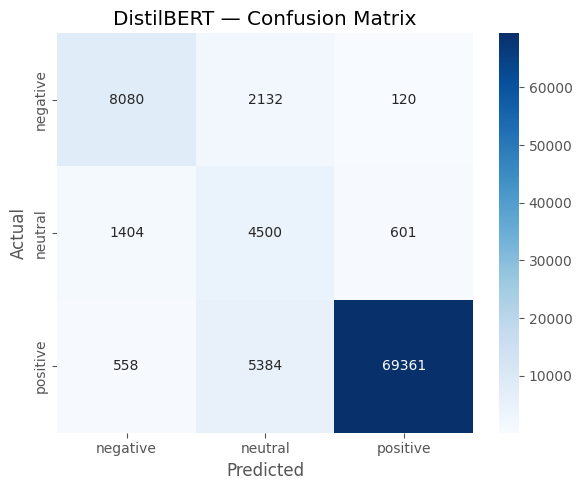

In [247]:
# Оценка DistilBERT на тестовой выборке
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

eval_args = TrainingArguments(
    output_dir=DISTILBERT_DIR,
    per_device_eval_batch_size=128,
    fp16=torch.cuda.is_available(),
    report_to="none",
)
eval_trainer = Trainer(
    model=distilbert,
    args=eval_args,
    data_collator=DataCollatorWithPadding(tokenizer),
    tokenizer=tokenizer,
)

pred = eval_trainer.predict(test_ds)
y_pred_bert = pred.predictions.argmax(-1)
y_true_bert = np.array(test_labels)

print(classification_report(y_true_bert, y_pred_bert, target_names=LABELS, digits=3))
print(
    f"accuracy={accuracy_score(y_true_bert, y_pred_bert):.3f}  "
    f"macro_f1={f1_score(y_true_bert, y_pred_bert, average='macro'):.3f}  "
    f"weighted_f1={f1_score(y_true_bert, y_pred_bert, average='weighted'):.3f}"
)

# Confusion matrix
cm = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS
)
plt.title("DistilBERT — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Сравнение всех моделей и общий вывод

Все модели оценены на одной и той же тестовой выборке (92 140 отзывов, разбиение с `random_state=42`).

| Модель | accuracy | macro F1 | weighted F1 | recall (neutral) |
|---|---|---|---|---|
| Logistic Regression | 0.862 | 0.694 | 0.879 | 0.60 |
| LinearSVC (по умолчанию) | 0.901 | 0.657 | 0.886 | 0.17 |
| LightGBM | 0.859 | 0.696 | 0.877 | 0.62 |
| LinearSVC (после подбора) | 0.896 | 0.717 | 0.899 | 0.464 |
| **DistilBERT (дообученный)** | 0.889 | **0.744** | **0.903** | **0.692** |

На несбалансированных данных (около 82% класса `positive`) accuracy малоинформативна, поэтому основными метриками служат macro-F1 (среднее значение F1 по трём классам с равным весом) и recall класса `neutral` — самого трудного для распознавания.

- По **macro-F1** DistilBERT даёт 0.744 — выше и исходных baseline, и настроенного LinearSVC (0.717). По **weighted-F1** (0.903) он также лучший.
- Наибольшая разница — на классе **`neutral`**: его recall у DistilBERT равен 0.69 против 0.46 у настроенного baseline и 0.17 у варианта по умолчанию. Модель находит около двух третей нейтральных отзывов, тогда как baseline пропускал большинство из них.
- Преимущество достигнуто ценой небольшого снижения accuracy (0.889) и невысокой precision на `neutral` (0.375): взвешенный loss заставляет модель чаще предсказывать `neutral`, увеличивая число как верных, так и ошибочных предсказаний этого класса. На несбалансированной задаче такой обмен оправдан.

Общий вывод: аккуратный подбор гиперпараметров заметно усиливает классический baseline, однако модель, учитывающая контекст и порядок слов, всё же превосходит его по ключевым метрикам. Основное ограничение TF-IDF-моделей связано со способом представления текста — частоты отдельных слов и биграмм не передают смысл предложения целиком, — а не с объёмом данных.


## 13. Дополнительно: тематическое моделирование на трансформере (BERTopic)

LDA в разделе 6 строит темы по частотам слов и требует заранее задать их число (мы взяли 12). У такого подхода два ограничения: он не учитывает смысл (синонимы для него — разные слова) и относит к какой-нибудь теме каждый отзыв, даже расплывчатый.

Для сравнения здесь добавлен **BERTopic** — тематическое моделирование на смысловых эмбеддингах предложений. Он переводит каждый отзыв в вектор-смысл (той же трансформерной техникой, что и в разделе 12), группирует близкие по смыслу отзывы и сам определяет число тем. Отзывы, не похожие ни на одну группу, он оставляет отдельно — как «выбросы», которые мы показываем как категорию «Прочее».

Это **дополнительный, исследовательский раздел**. LDA и дашборд остаются без изменений; цель — показать, что даёт современный подход, и сравнить его с LDA.

Этапы: эмбеддинги отзывов на GPU (модель MiniLM) → снижение размерности (UMAP) и кластеризация (HDBSCAN) внутри BERTopic → характерные слова каждой темы (c-TF-IDF). Расчёт идёт на выборке 50 000 отзывов. Результат кэшируется в `models/bertopic_topics_*.csv`: при наличии файлов раздел просто показывает таблицы, иначе пересчитывает заново.


In [248]:
# Тематическое моделирование на трансформере. Результат кэшируется в CSV:
# если таблицы есть — просто показываем их, иначе считаем BERTopic на GPU.
import os

AUTO_CSV = "models/bertopic_topics_auto.csv"
REDUCED_CSV = "models/bertopic_topics_reduced25.csv"

if not (os.path.exists(AUTO_CSV) and os.path.exists(REDUCED_CSV)):
    import re
    from html import unescape

    import torch
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    from sklearn.feature_extraction.text import CountVectorizer

    def light_clean(t):
        t = unescape(str(t))
        t = re.sub(r"<[^>]+>", " ", t)
        return re.sub(r"\s+", " ", t).strip()

    docs = (
        reviews["title"].fillna("").astype(str)
        + ". "
        + reviews["text"].fillna("").astype(str)
    )
    docs = docs.sample(n=min(50_000, len(docs)), random_state=42).map(light_clean).tolist()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    embedder = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    embeddings = embedder.encode(docs, batch_size=256, show_progress_bar=True)

    vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=10)
    bertopic_model = BERTopic(
        embedding_model=embedder,
        vectorizer_model=vectorizer,
        min_topic_size=150,
        calculate_probabilities=False,
        verbose=True,
    )
    bertopic_model.fit_transform(docs, embeddings)
    bertopic_model.get_topic_info().to_csv(AUTO_CSV, index=False)
    bertopic_model.reduce_topics(docs, nr_topics=25)
    bertopic_model.get_topic_info().to_csv(REDUCED_CSV, index=False)

auto_topics = pd.read_csv(AUTO_CSV)
reduced_topics = pd.read_csv(REDUCED_CSV)


def topic_summary(df, title):
    n = int((df["Topic"] >= 0).sum())
    other = int(df.loc[df["Topic"] == -1, "Count"].iloc[0]) if (df["Topic"] == -1).any() else 0
    share = other / df["Count"].sum() * 100
    print(f"{title}: {n} тем + «Прочее» {other:,} ({share:.0f}%)")


topic_summary(auto_topics, "BERTopic (автоматически)")
topic_summary(reduced_topics, "BERTopic (сведено к ~25)")

# Таблица тем сведённой версии; выбросы показываем как «Прочее»
view = reduced_topics[["Topic", "Count", "Name"]].copy()
view["Name"] = view.apply(
    lambda r: "Прочее (всякое)" if r["Topic"] == -1 else r["Name"], axis=1
)
view


BERTopic (автоматически): 66 тем + «Прочее» 23,170 (46%)
BERTopic (сведено к ~25): 24 тем + «Прочее» 23,170 (46%)


,Topic,Count,Name
0,-1,23170,Прочее (всякое)
1,0,3533,0_pillow_soft_bed_sheets
2,1,3020,1_pan_eggs_pans_pot
3,2,2405,2_bags_bag_bowls_glasses
4,3,2235,3_tree_gift_frame_cute
5,4,1895,4_coffee_tea_cup_water
6,5,1736,5_chair_table_desk_chairs
7,6,1690,6_sturdy_shelves_shelf_storage
8,7,1664,7_curtain_curtains_shower_rod
9,8,1495,8_towels_mat_towel_soft


### Сравнение LDA и BERTopic

| | LDA (раздел 6) | BERTopic |
|---|---|---|
| Число тем | 12, задаётся вручную | определяется само: около 65 (можно свести к ~25) |
| Основа | частоты слов, без учёта смысла | смысловые эмбеддинги предложений |
| Гранулярность | широкие, иногда смешанные категории | узкие и конкретные |
| Расплывчатые отзывы | принудительно отнесены к какой-то теме | вынесены в отдельную группу «Прочее» (~46%) |

**Что показало сравнение:**
- BERTopic разделяет то, что LDA объединял. Где у LDA одна тема «Bedding & Sleep», BERTopic выделяет отдельно подушки, матрасы, простыни и одеяла; вместо смешанной «Furniture & Cutlery» — отдельно «стулья и столы» и «ножи». Темы получаются более конкретными и пригодными для конкретных решений.
- BERTopic сам нашёл около 65 тем — заметно больше заданных вручную 12, и это ближе к реальному разнообразию товаров в категории Home & Kitchen.
- Около 46% отзывов отнесены к группе «Прочее»: это короткие и общие отзывы («great», «love it», «works well»), которые не несут темы. LDA распределил бы их по категориям принудительно; BERTopic честно выделяет их отдельно.

**Цена подхода:** BERTopic тяжелее — нужны эмбеддинги на GPU и дополнительные библиотеки, а результат не детерминирован по умолчанию (UMAP вносит случайность). Поэтому основной моделью тем в проекте и дашборде оставлен LDA: он быстрый, воспроизводимый и достаточный для обзорной аналитики. BERTopic показан как более точная альтернатива, к которой имеет смысл переходить, когда нужна детальная сегментация по конкретным товарам.
